# Research Questions: Prediksi Kandungan Organik Tanah

Notebook ini secara khusus menjawab sepuluh *research questions* setelah tahap prediksi kompetisi.
Seluruh analisis bersifat **mandiri**: data dibaca langsung dari `data/train.csv`, fitur dibangun ulang,
dan model dievaluasi ulang tanpa bergantung pada variabel atau output `main.ipynb`.

**Prinsip interpretasi**

- Hasil numerik di notebook berasal dari training dataset.
- Hubungan yang ditemukan adalah asosiasi, bukan bukti kausal.
- Label `Cerrado`, `Mata Atlantica`, `Amazonia`, dan `Caatinga` menunjukkan bahwa konteks ekologis
  dataset adalah Brasil. Klaim ekologis dibatasi pada konteks tersebut.
- Model diposisikan sebagai alat *screening* dan pendukung keputusan, bukan pengganti mutlak pengujian
  laboratorium.

## Pemetaan bobot dan bukti analisis

| Bagian | Bobot | Bukti utama |
|---|---:|---|
| Submisi kompetisi | 10% | Dibahas di `main.ipynb` dan `submission.csv` |
| Soal 1 | 2,5% | Analisis keputusan dan literatur FAO/IPCC |
| Soal 2 | 10% | 5-fold final blend, GroupKFold, learning curve, residual |
| Soal 3 | 12,5% | Kruskal-Wallis, effect size, post-hoc Holm |
| Soal 4 | 7,5% | Bootstrap CI, rasio mean, korelasi hierarki |
| Soal 5a | 5% | Filter statistik dan bootstrap per bioma |
| Soal 5b | 5% | IQR per kelompok dan sensitivity check MAD |
| Soal 6 | 7,5% | Spearman, clustered heatmap, VIF |
| Soal 7 | 10% | Ablation study bertahap dan audit `source_id` |
| Soal 8 | 10% | Benchmark Dummy, PLS, CatBoost, ExtraTrees, dan final weighted blend |
| Soal 9 | 10% | RMSE, MAE, MedianAE, RMSLE, error per desil |
| Soal 10 | 10% | Rancangan integrasi data eksternal dan leakage control |

## Setup, data, dan fungsi bantuan

In [1]:
import os
import time
import warnings
from itertools import combinations
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str((Path.cwd() / ".mplconfig").resolve())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from catboost import CatBoostRegressor

RANDOM_STATE = 42
TARGET = "property_organic_content"
N_FOLDS = 5
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
GREEN = "#2D6A4F"
LIGHT_GREEN = "#74C69D"
DARK_GREEN = "#1B4332"
ORANGE = "#F4A261"
RED = "#C1121F"
BLUE = "#457B9D"
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

train = pd.read_csv(DATA_DIR / "train.csv")
y = train[TARGET].copy()

assert TARGET in train.columns
assert train["sample_id"].is_unique
print(f"Train shape: {train.shape}")
print(f"Target mean: {y.mean():.4f} | median: {y.median():.4f} | skewness: {y.skew():.4f}")

Matplotlib is building the font cache; this may take a moment.


Train shape: (11210, 52)
Target mean: 34.1425 | median: 27.5065 | skewness: 2.0278


In [2]:
def regression_metrics(y_true, y_pred):
    y_pred_nonnegative = np.clip(np.asarray(y_pred), 0, None)
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, y_pred_nonnegative)),
        "R2": r2_score(y_true, y_pred),
    }


def bootstrap_mean_ci(values, n_boot=500, confidence=0.95, seed=RANDOM_STATE):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return values[0], values[0]
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = 1 - confidence
    return (
        np.quantile(boot_means, alpha / 2),
        np.quantile(boot_means, 1 - alpha / 2),
    )


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.maximum.accumulate(
        (len(p_values) - np.arange(len(p_values))) * p_values[order]
    )
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.clip(adjusted_sorted, 0, 1)
    return adjusted


def eta_squared(data, group_col, target_col=TARGET):
    grand_mean = data[target_col].mean()
    ss_between = sum(
        len(group) * (group[target_col].mean() - grand_mean) ** 2
        for _, group in data.groupby(group_col)
    )
    ss_total = ((data[target_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total


def make_features(df, stage="full", drop_source=False):
    stage_order = {
        "raw": 0,
        "missingness": 1,
        "spectral": 2,
        "soil": 3,
        "geographic": 4,
        "full": 5,
    }
    if stage not in stage_order:
        raise ValueError(f"Stage tidak dikenal: {stage}")

    level = stage_order[stage]
    X = df.drop(columns=[TARGET, "sample_id"], errors="ignore").copy()
    if drop_source:
        X = X.drop(columns=["source_id"], errors="ignore")

    band_a = [c for c in X.columns if c.startswith("spectral_band_A_PC_")]
    band_b = [c for c in X.columns if c.startswith("spectral_band_B_PC_")]
    chemistry = [
        "property_acidity_index", "cation_Ca", "cation_Mg",
        "cation_Na", "cation_exchange_capacity",
    ]

    if level >= 1:
        X["missing_total"] = X.isna().sum(axis=1)
        X["chem_missing_count"] = X[chemistry].isna().sum(axis=1)
        X["band_B_available_actual"] = np.where(
            X[band_b].notna().any(axis=1), "YES", "NO"
        )
        X["band_B_missing_count"] = X[band_b].isna().sum(axis=1)
        X["coordinates_available"] = np.where(
            X[["latitude", "longitude"]].notna().all(axis=1), "YES", "NO"
        )

    if level >= 2:
        for prefix, cols in [("A", band_a), ("B", band_b)]:
            values = X[cols]
            X[f"spectral_{prefix}_mean"] = values.mean(axis=1)
            X[f"spectral_{prefix}_std"] = values.std(axis=1)
            X[f"spectral_{prefix}_l2"] = np.sqrt((values ** 2).sum(axis=1))
            X[f"spectral_{prefix}_max_abs"] = values.abs().max(axis=1)
            X[f"spectral_{prefix}_abs_sum"] = values.abs().sum(axis=1)
            X[f"spectral_{prefix}_pos_count"] = (values > 0).sum(axis=1)

    if level >= 3:
        eps = 1e-6
        X["particle_total"] = (
            X["property_particle_coarse"] + X["property_particle_fine"]
        )
        X["fine_fraction"] = (
            X["property_particle_fine"] / (X["particle_total"] + eps)
        )
        X["coarse_fine_ratio"] = (
            X["property_particle_coarse"]
            / (X["property_particle_fine"].abs() + eps)
        )
        X["base_cation_sum"] = X[
            ["cation_Ca", "cation_Mg", "cation_Na"]
        ].sum(axis=1, min_count=1)
        X["ca_mg_ratio"] = X["cation_Ca"] / (X["cation_Mg"].abs() + eps)
        X["base_to_cec_ratio"] = (
            X["base_cation_sum"]
            / (X["cation_exchange_capacity"].abs() + eps)
        )
        X["log_cec"] = np.log1p(
            X["cation_exchange_capacity"].clip(lower=0)
        )

    if level >= 4:
        X["geo_hierarchy"] = (
            X["geo_zone_macro"].astype(str) + "|"
            + X["geo_zone_meso"].astype(str) + "|"
            + X["geo_zone_micro"].astype(str)
        )
        X["biome_landcover"] = (
            X["biome"].astype(str) + "|"
            + X["land_cover_type"].astype(str)
        )
        if "source_id" in X.columns:
            band_flag = (
                X["band_B_available_actual"]
                if "band_B_available_actual" in X.columns
                else np.where(X[band_b].notna().any(axis=1), "YES", "NO")
            )
            X["source_bandB"] = X["source_id"].astype(str) + "|" + band_flag
        X["macro_biome"] = X["geo_zone_macro"].astype(str) + "|" + X["biome"].astype(str)
        X["macro_landcover"] = (
            X["geo_zone_macro"].astype(str) + "|" + X["land_cover_type"].astype(str)
        )

    if level >= 5:
        X["lat_round_1"] = X["latitude"].round(1)
        X["lon_round_1"] = X["longitude"].round(1)

    categorical_cols = X.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    for col in categorical_cols:
        X[col] = X[col].fillna("Missing").astype(str)
    return X, categorical_cols


X_full, cat_cols_full = make_features(train, stage="full")
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
stratified_cv = StratifiedKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE
)
cv_splits = list(stratified_cv.split(X_full, y_bins))
print(f"Engineered feature shape: {X_full.shape}")

Engineered feature shape: (11210, 81)


## Ringkasan data sebelum menjawab pertanyaan

Ringkasan ini digunakan untuk memahami representasi data dan potensi bias sampel.

,nilai
jumlah_sampel,"11,210.0000"
jumlah_fitur,51.0000
jumlah_source,35.0000
jumlah_zona_macro,5.0000
jumlah_zona_meso,23.0000
jumlah_zona_micro,50.0000
band_B_missing_pct,84.8885
target_mean,34.1425
target_median,27.5065
target_skewness,2.0278


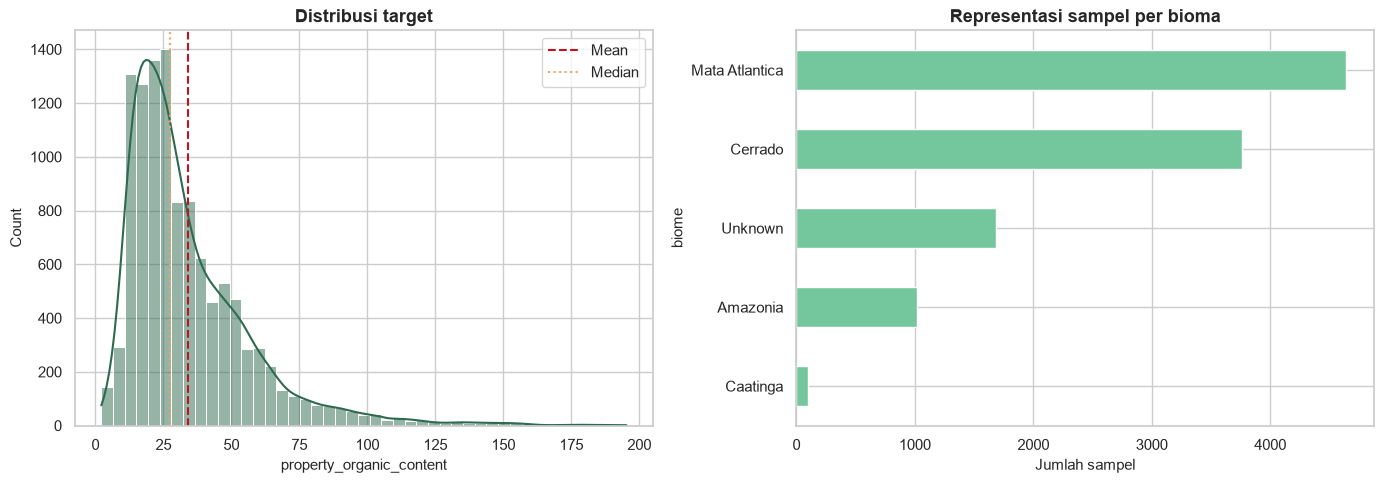

In [3]:
band_b_cols = [c for c in train.columns if c.startswith("spectral_band_B_PC_")]
overview = pd.Series({
    "jumlah_sampel": len(train),
    "jumlah_fitur": train.shape[1] - 1,
    "jumlah_source": train["source_id"].nunique(),
    "jumlah_zona_macro": train["geo_zone_macro"].nunique(),
    "jumlah_zona_meso": train["geo_zone_meso"].nunique(),
    "jumlah_zona_micro": train["geo_zone_micro"].nunique(),
    "band_B_missing_pct": train[band_b_cols].isna().all(axis=1).mean() * 100,
    "target_mean": y.mean(),
    "target_median": y.median(),
    "target_skewness": y.skew(),
})
display(overview.to_frame("nilai"))

_, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, bins=45, kde=True, color=GREEN, ax=axes[0])
axes[0].axvline(y.mean(), color=RED, ls="--", label="Mean")
axes[0].axvline(y.median(), color=ORANGE, ls=":", label="Median")
axes[0].set_title("Distribusi target")
axes[0].legend()

train["biome"].value_counts().sort_values().plot(
    kind="barh", color=LIGHT_GREEN, ax=axes[1]
)
axes[1].set_title("Representasi sampel per bioma")
axes[1].set_xlabel("Jumlah sampel")
plt.tight_layout()
plt.show()

# Soal 1 — Urgensi bisnis dan kebijakan pangan

> **Dalam konteks bisnis pertanian dan kebijakan pangan, apakah memprediksi kandungan organik tanah
> merupakan hal yang mendesak? Jelaskan urgensinya dari perspektif efisiensi biaya operasional dan
> manajemen lahan berkelanjutan!**

## Pendekatan dan asumsi

Jawaban menggabungkan konteks dataset dengan literatur FAO dan IPCC. Karena dataset tidak menyediakan
data biaya, notebook tidak mengarang nominal penghematan. Efisiensi dijelaskan melalui perubahan alur
kerja dan alokasi sumber daya.

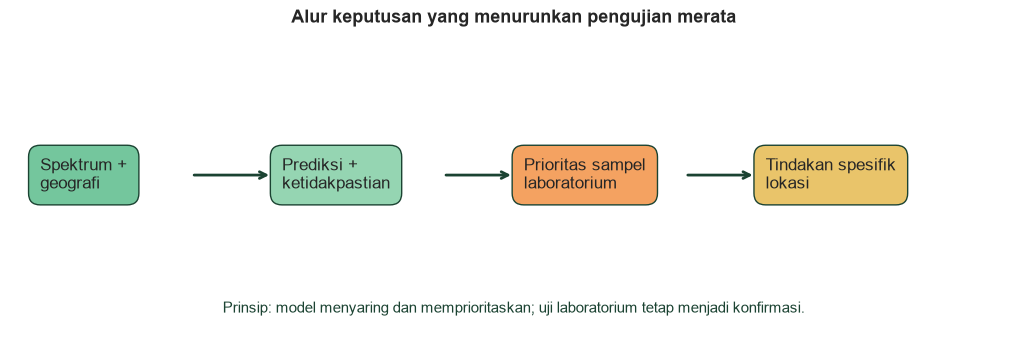

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.axis("off")
boxes = [
    (0.03, "Spektrum +\ngeografi", LIGHT_GREEN),
    (0.27, "Prediksi +\nketidakpastian", "#95D5B2"),
    (0.51, "Prioritas sampel\nlaboratorium", ORANGE),
    (0.75, "Tindakan spesifik\nlokasi", "#E9C46A"),
]
for x, label, color in boxes:
    ax.text(
        x, 0.55, label, ha="left", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.7", fc=color, ec=DARK_GREEN)
    )
for x1, x2 in [(0.18, 0.26), (0.43, 0.50), (0.67, 0.74)]:
    ax.annotate("", xy=(x2, 0.55), xytext=(x1, 0.55),
                arrowprops=dict(arrowstyle="->", lw=2, color=DARK_GREEN))
ax.text(
    0.5, 0.08,
    "Prinsip: model menyaring dan memprioritaskan; uji laboratorium tetap menjadi konfirmasi.",
    ha="center", fontsize=11, color=DARK_GREEN
)
ax.set_title("Alur keputusan yang menurunkan pengujian merata", pad=15)
plt.show()

## Jawaban Soal 1

**Ya, prediksi kandungan organik tanah mendesak sebagai alat screening dan prioritisasi.**

1. **Efisiensi biaya operasional.** Pengujian laboratorium merata membutuhkan pengambilan sampel,
   transportasi, preparasi, reagen, instrumen, dan waktu analis. Model dapat membuat peta risiko awal,
   sehingga laboratorium difokuskan pada lokasi bernilai ekstrem, berketidakpastian tinggi, atau penting
   secara kebijakan. Penghematan berasal dari *targeted sampling*, bukan dari menghapus laboratorium.
2. **Efisiensi input pertanian.** Kandungan organik berkaitan dengan kesuburan, retensi air, struktur
   tanah, dan jasa ekosistem. Informasi spasial yang lebih cepat mendukung pemberian bahan organik,
   pemupukan, dan konservasi yang spesifik lokasi.
3. **Manajemen berkelanjutan.** Prediksi berulang membantu mendeteksi degradasi dan memprioritaskan
   rehabilitasi. FAO menyatakan bahwa soil organic carbon penting bagi kesehatan, kesuburan, produksi
   pangan, dan jasa ekosistem; IPCC juga menempatkan pengelolaan lahan berkelanjutan sebagai bagian dari
   ketahanan pangan dan mitigasi/adaptasi iklim.
4. **Batas keputusan.** Model tidak mengukur stok karbon secara langsung dan tidak membuktikan sebab
   perubahan. Keputusan berisiko tinggi tetap memerlukan konfirmasi laboratorium, audit error per
   wilayah, dan pembaruan model.

**Kesimpulan:** urgensinya tinggi ketika model dipakai untuk mempercepat dan memprioritaskan tindakan,
bukan ketika diposisikan sebagai pengganti absolut metode referensi.

Referensi: [FAO — Soil Organic Carbon](https://www.fao.org/global-soil-partnership/areas-of-work/soil-organic-carbon/en/);
[IPCC — Climate Change and Land](https://www.ipcc.ch/srccl/).

**Keterbatasan:** dataset tidak memiliki komponen biaya dan tanggal pemantauan, sehingga besaran ROI
serta kemampuan mendeteksi tren waktu belum dapat dihitung.

# Soal 2 - Overfit atau underfit

> **Apakah model prediksi kandungan organik tanah Anda mengalami overfit atau underfit? Tunjukkan
> buktinya secara empiris melalui metrik evaluasi atau melalui visualisasi yang relevan, serta jelaskan
> langkah mitigasi yang Anda lakukan! Jika tidak mengalami keduanya, jelaskan alasannya!**

## Pendekatan dan asumsi

Diagnosis menggunakan:

- 5-fold stratified cross-validation berdasarkan desil target;
- final weighted blend yang sama dengan `main.ipynb`: 47,5% CatBoost dan 52,5% ExtraTrees;
- selisih train dan validation RMSE pada prediksi blend;
- learning curve CatBoost dan residual OOF final blend;
- GroupKFold berdasarkan `source_id` sebagai stress test untuk sumber/laboratorium baru;
- evaluasi terpisah untuk sampel dengan dan tanpa band B.

In [5]:
BLEND_CATBOOST_WEIGHT = 0.475
BLEND_EXTRATREES_WEIGHT = 1 - BLEND_CATBOOST_WEIGHT

cat_oof = np.zeros(len(train))
et_oof = np.zeros(len(train))
oof_pred = np.zeros(len(train))
fold_metrics_rows = []
eval_histories = []
catboost_fold_times = []
extratrees_fold_times = []
importance_rows = []

numeric_full_cols = X_full.select_dtypes(include=np.number).columns.tolist()
categorical_full_cols = [c for c in X_full.columns if c not in numeric_full_cols]

for fold, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
    cat_model = CatBoostRegressor(
        iterations=1000,
        depth=6,
        learning_rate=0.045,
        l2_leaf_reg=8,
        random_strength=1.2,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE + fold,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )
    started = time.perf_counter()
    cat_model.fit(
        X_full.iloc[train_idx], y.iloc[train_idx],
        cat_features=cat_cols_full,
        eval_set=(X_full.iloc[valid_idx], y.iloc[valid_idx]),
        early_stopping_rounds=130,
        verbose=False,
    )
    cat_elapsed = time.perf_counter() - started
    catboost_fold_times.append(cat_elapsed)

    extra_preprocessor = ColumnTransformer([
        ("numeric", SimpleImputer(strategy="median"), numeric_full_cols),
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        ), categorical_full_cols),
    ])
    extra_model = Pipeline([
        ("preprocess", extra_preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=600,
            min_samples_leaf=2,
            max_features=0.8,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
        )),
    ])
    started = time.perf_counter()
    extra_model.fit(X_full.iloc[train_idx], y.iloc[train_idx])
    et_elapsed = time.perf_counter() - started
    extratrees_fold_times.append(et_elapsed)

    cat_train_pred = cat_model.predict(X_full.iloc[train_idx])
    cat_valid_pred = cat_model.predict(X_full.iloc[valid_idx])
    et_train_pred = extra_model.predict(X_full.iloc[train_idx])
    et_valid_pred = extra_model.predict(X_full.iloc[valid_idx])

    blend_train_pred = (
        BLEND_CATBOOST_WEIGHT * cat_train_pred
        + BLEND_EXTRATREES_WEIGHT * et_train_pred
    )
    blend_valid_pred = (
        BLEND_CATBOOST_WEIGHT * cat_valid_pred
        + BLEND_EXTRATREES_WEIGHT * et_valid_pred
    )

    cat_oof[valid_idx] = cat_valid_pred
    et_oof[valid_idx] = et_valid_pred
    oof_pred[valid_idx] = blend_valid_pred
    eval_histories.append(cat_model.get_evals_result())
    importance_rows.append(pd.DataFrame({
        "feature": X_full.columns,
        "importance": cat_model.get_feature_importance(),
        "fold": fold,
    }))
    fold_metrics_rows.append({
        "fold": fold,
        "catboost_best_iteration": cat_model.get_best_iteration(),
        "catboost_validation_RMSE": root_mean_squared_error(y.iloc[valid_idx], cat_valid_pred),
        "extratrees_validation_RMSE": root_mean_squared_error(y.iloc[valid_idx], et_valid_pred),
        "train_RMSE": root_mean_squared_error(y.iloc[train_idx], blend_train_pred),
        "validation_RMSE": root_mean_squared_error(y.iloc[valid_idx], blend_valid_pred),
        "validation_MAE": mean_absolute_error(y.iloc[valid_idx], blend_valid_pred),
        "validation_R2": r2_score(y.iloc[valid_idx], blend_valid_pred),
        "seconds": cat_elapsed + et_elapsed,
    })
    print(f"Fold {fold} selesai ({cat_elapsed + et_elapsed:.1f} detik).")

fold_metrics = pd.DataFrame(fold_metrics_rows).set_index("fold")
oof_metrics = pd.Series(regression_metrics(y, oof_pred), name="Final blend OOF")
model_comparison = pd.DataFrame([
    {"model": "CatBoost 5-fold", **regression_metrics(y, cat_oof)},
    {"model": "ExtraTrees 5-fold", **regression_metrics(y, et_oof)},
    {"model": f"Final blend {BLEND_CATBOOST_WEIGHT:.3f}/{BLEND_EXTRATREES_WEIGHT:.3f}", **regression_metrics(y, oof_pred)},
]).set_index("model").sort_values("RMSE")

display(fold_metrics)
display(model_comparison)
display(oof_metrics.to_frame())

Fold 1 selesai (158.2 detik).


Fold 2 selesai (153.5 detik).


Fold 3 selesai (159.5 detik).


Fold 4 selesai (158.5 detik).


Fold 5 selesai (151.9 detik).


,catboost_best_iteration,catboost_validation_RMSE,extratrees_validation_RMSE,train_RMSE,validation_RMSE,validation_MAE,validation_R2,seconds
fold,,,,,,,,
1,998,11.9568,11.9719,5.0683,11.6695,7.2857,0.7507,158.1923
2,999,11.7377,11.7836,5.2143,11.3708,7.0863,0.7580,153.4806
3,999,11.9538,11.5812,5.0769,11.4390,7.2695,0.7629,159.5472
4,984,11.8754,11.9969,5.1686,11.6114,7.1105,0.7597,158.4515
5,994,10.9466,10.9349,5.2609,10.5977,6.8201,0.7740,151.8863


,RMSE,MAE,MedianAE,RMSLE,R2
model,,,,,
Final blend 0.475/0.525,11.3442,7.1144,4.5046,0.3030,0.7609
ExtraTrees 5-fold,11.6602,7.2919,4.5528,0.3105,0.7473
CatBoost 5-fold,11.7003,7.3734,4.6680,0.3122,0.7456


,Final blend OOF
RMSE,11.3442
MAE,7.1144
MedianAE,4.5046
RMSLE,0.3030
R2,0.7609


In [6]:
group_oof = np.zeros(len(train))
group_rows = []
group_cv = GroupKFold(n_splits=3)

for fold, (train_idx, valid_idx) in enumerate(
    group_cv.split(X_full, y, groups=train["source_id"]), start=1
):
    group_cat = CatBoostRegressor(
        iterations=450,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=10,
        random_strength=1.2,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=100 + fold,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )
    group_cat.fit(
        X_full.iloc[train_idx], y.iloc[train_idx],
        cat_features=cat_cols_full,
        eval_set=(X_full.iloc[valid_idx], y.iloc[valid_idx]),
        early_stopping_rounds=80,
        verbose=False,
    )

    group_preprocessor = ColumnTransformer([
        ("numeric", SimpleImputer(strategy="median"), numeric_full_cols),
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        ), categorical_full_cols),
    ])
    group_et = Pipeline([
        ("preprocess", group_preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=450,
            min_samples_leaf=2,
            max_features=0.8,
            random_state=100 + fold,
            n_jobs=-1,
        )),
    ])
    group_et.fit(X_full.iloc[train_idx], y.iloc[train_idx])

    pred = (
        BLEND_CATBOOST_WEIGHT * group_cat.predict(X_full.iloc[valid_idx])
        + BLEND_EXTRATREES_WEIGHT * group_et.predict(X_full.iloc[valid_idx])
    )
    group_oof[valid_idx] = pred
    group_rows.append({
        "fold": fold,
        "n_valid": len(valid_idx),
        "n_source_valid": train.iloc[valid_idx]["source_id"].nunique(),
        "RMSE": root_mean_squared_error(y.iloc[valid_idx], pred),
        "MAE": mean_absolute_error(y.iloc[valid_idx], pred),
    })
    print(f"Group fold {fold} selesai.")

group_metrics = pd.DataFrame(group_rows).set_index("fold")
group_overall = pd.Series(regression_metrics(y, group_oof), name="GroupKFold final blend OOF")
display(group_metrics)
display(group_overall.to_frame())

Group fold 1 selesai.


Group fold 2 selesai.


Group fold 3 selesai.


,n_valid,n_source_valid,RMSE,MAE
fold,,,,
1,3986,1,8.5271,6.4672
2,3614,14,16.1633,11.0404
3,3610,20,25.8513,18.1452


,GroupKFold final blend OOF
RMSE,18.0358
MAE,11.7023
MedianAE,7.7840
RMSLE,0.4709
R2,0.3955


,n,RMSE,MAE,MedianAE,RMSLE,R2
kelompok,,,,,,
Band B tersedia,1694,12.4066,7.8841,5.1799,0.3234,0.7840
Band B tidak tersedia,9516,11.1445,6.9774,4.4171,0.2992,0.7545


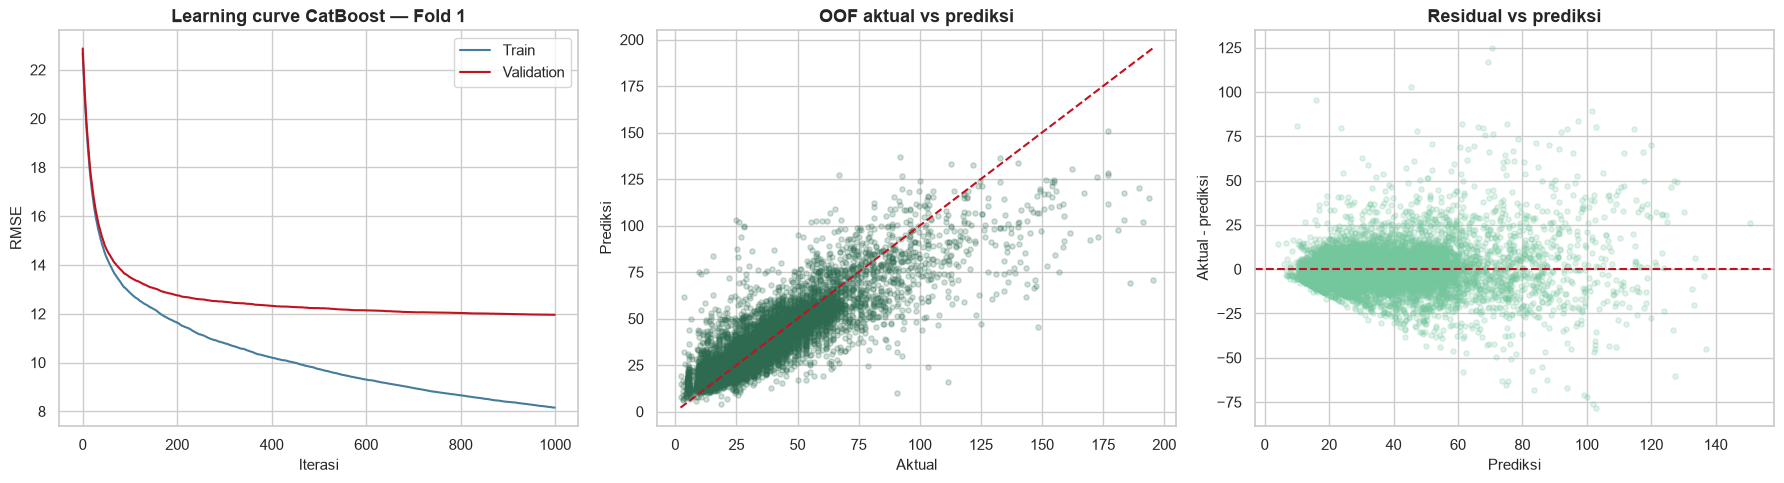

In [7]:
residuals = y - oof_pred
band_b_available = train[band_b_cols].notna().any(axis=1)
band_b_metrics = pd.DataFrame([
    {
        "kelompok": "Band B tersedia",
        "n": band_b_available.sum(),
        **regression_metrics(y[band_b_available], oof_pred[band_b_available]),
    },
    {
        "kelompok": "Band B tidak tersedia",
        "n": (~band_b_available).sum(),
        **regression_metrics(y[~band_b_available], oof_pred[~band_b_available]),
    },
]).set_index("kelompok")
display(band_b_metrics)

_, axes = plt.subplots(1, 3, figsize=(18, 5))
first_history = eval_histories[0]
axes[0].plot(first_history["learn"]["RMSE"], label="Train", color=BLUE)
axes[0].plot(first_history["validation"]["RMSE"], label="Validation", color=RED)
axes[0].set_title("Learning curve CatBoost — Fold 1")
axes[0].set_xlabel("Iterasi")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].scatter(y, oof_pred, alpha=0.22, s=14, color=GREEN)
lims = [min(y.min(), oof_pred.min()), max(y.max(), oof_pred.max())]
axes[1].plot(lims, lims, "--", color=RED)
axes[1].set_title("OOF aktual vs prediksi")
axes[1].set_xlabel("Aktual")
axes[1].set_ylabel("Prediksi")

axes[2].scatter(oof_pred, residuals, alpha=0.22, s=14, color=LIGHT_GREEN)
axes[2].axhline(0, ls="--", color=RED)
axes[2].set_title("Residual vs prediksi")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("Aktual - prediksi")
plt.tight_layout()
plt.show()

In [8]:
mean_train_rmse = fold_metrics["train_RMSE"].mean()
mean_valid_rmse = fold_metrics["validation_RMSE"].mean()
generalization_gap = mean_valid_rmse - mean_train_rmse
gap_pct = generalization_gap / mean_valid_rmse * 100

cat_rmse = model_comparison.loc["CatBoost 5-fold", "RMSE"]
et_rmse = model_comparison.loc["ExtraTrees 5-fold", "RMSE"]

if generalization_gap > 4:
    diagnosis = "overfit cukup jelas pada training fit, tetapi generalisasi OOF membaik setelah blending"
elif generalization_gap > 1:
    diagnosis = "overfit ringan hingga moderat"
else:
    diagnosis = "tidak menunjukkan overfit kuat"

display(Markdown(f'''
## Jawaban Soal 2

Model final menunjukkan **{diagnosis}**, bukan underfit.

- Mean train RMSE final blend: **{mean_train_rmse:.3f}**
- Mean validation RMSE final blend: **{mean_valid_rmse:.3f}**
- Generalization gap: **{generalization_gap:.3f}** atau **{gap_pct:.1f}%**
- CatBoost OOF RMSE: **{cat_rmse:.3f}**
- ExtraTrees OOF RMSE: **{et_rmse:.3f}**
- Final blend OOF RMSE: **{oof_metrics["RMSE"]:.3f}**
- Final blend OOF R^2: **{oof_metrics["R2"]:.3f}**
- GroupKFold OOF RMSE berdasarkan `source_id`: **{group_overall["RMSE"]:.3f}**

R^2 OOF yang substantif dan performa yang jauh lebih baik dari prediksi konstan menunjukkan model tidak
underfit. Namun, train RMSE lebih rendah daripada validation RMSE dan GroupKFold lebih sulit daripada
random CV. Ini menunjukkan bahwa sebagian sinyal bersifat spesifik sumber/laboratorium atau wilayah.
Plot residual juga memperlihatkan penyebaran error membesar pada prediksi tinggi dan kecenderungan
meratakan nilai ekstrem.

**Mitigasi yang telah digunakan:** kedalaman pohon dibatasi, regularisasi L2, `random_strength`,
early stopping, averaging antar-fold, weighted blending CatBoost-ExtraTrees, dan indikator missingness.
Untuk deployment pada sumber baru, GroupKFold/spatial blocking harus menjadi kriteria seleksi utama dan
`source_id` perlu diuji melalui ablation.

**Keterbatasan:** GroupKFold berdasarkan `source_id` adalah stress test domain shift, tetapi tidak sama
dengan spatial blocking murni karena satu sumber dapat mencakup lebih dari satu wilayah.
'''))


## Jawaban Soal 2

Model final menunjukkan **overfit cukup jelas pada training fit, tetapi generalisasi OOF membaik setelah blending**, bukan underfit.

- Mean train RMSE final blend: **5.158**
- Mean validation RMSE final blend: **11.338**
- Generalization gap: **6.180** atau **54.5%**
- CatBoost OOF RMSE: **11.700**
- ExtraTrees OOF RMSE: **11.660**
- Final blend OOF RMSE: **11.344**
- Final blend OOF R^2: **0.761**
- GroupKFold OOF RMSE berdasarkan `source_id`: **18.036**

R^2 OOF yang substantif dan performa yang jauh lebih baik dari prediksi konstan menunjukkan model tidak
underfit. Namun, train RMSE lebih rendah daripada validation RMSE dan GroupKFold lebih sulit daripada
random CV. Ini menunjukkan bahwa sebagian sinyal bersifat spesifik sumber/laboratorium atau wilayah.
Plot residual juga memperlihatkan penyebaran error membesar pada prediksi tinggi dan kecenderungan
meratakan nilai ekstrem.

**Mitigasi yang telah digunakan:** kedalaman pohon dibatasi, regularisasi L2, `random_strength`,
early stopping, averaging antar-fold, weighted blending CatBoost-ExtraTrees, dan indikator missingness.
Untuk deployment pada sumber baru, GroupKFold/spatial blocking harus menjadi kriteria seleksi utama dan
`source_id` perlu diuji melalui ablation.

**Keterbatasan:** GroupKFold berdasarkan `source_id` adalah stress test domain shift, tetapi tidak sama
dengan spatial blocking murni karena satu sumber dapat mencakup lebih dari satu wilayah.


# Soal 3 — Distribusi geografis dan ekosistem dominan

> **Apakah ada pola distribusi kandungan organik tanah yang berbeda secara signifikan antar wilayah
> geografis? Berdasarkan pola tersebut, kira-kira kondisi ekosistem seperti apa yang paling dominan
> dalam dataset ini? Jelaskan reasoning Anda berdasarkan informasi ekologis dan tutupan lahan yang
> terlihat!**

## Pendekatan dan asumsi

Target sangat right-skewed, sehingga perbedaan zona macro diuji dengan Kruskal-Wallis. Epsilon-squared
digunakan sebagai ukuran efek. Jika uji global signifikan, pasangan zona diuji dengan Mann-Whitney U
dan p-value dikoreksi menggunakan metode Holm.

In [9]:
macro_summary = (
    train.groupby("geo_zone_macro")[TARGET]
    .agg(count="size", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)
macro_groups = [
    group[TARGET].values for _, group in train.groupby("geo_zone_macro")
]
kw = stats.kruskal(*macro_groups)
k_macro = train["geo_zone_macro"].nunique()
epsilon_squared = (kw.statistic - k_macro + 1) / (len(train) - k_macro)

posthoc_rows = []
for zone_a, zone_b in combinations(sorted(train["geo_zone_macro"].unique()), 2):
    a = train.loc[train["geo_zone_macro"] == zone_a, TARGET]
    b = train.loc[train["geo_zone_macro"] == zone_b, TARGET]
    result = stats.mannwhitneyu(a, b, alternative="two-sided")
    rank_biserial = 2 * result.statistic / (len(a) * len(b)) - 1
    posthoc_rows.append({
        "zona_A": zone_a,
        "zona_B": zone_b,
        "U": result.statistic,
        "p_raw": result.pvalue,
        "rank_biserial": rank_biserial,
    })
posthoc = pd.DataFrame(posthoc_rows)
posthoc["p_holm"] = holm_adjust(posthoc["p_raw"])
posthoc["signifikan_5pct"] = posthoc["p_holm"] < 0.05

display(macro_summary)
print(
    f"Kruskal-Wallis H={kw.statistic:.3f}, p={kw.pvalue:.3e}, "
    f"epsilon-squared={epsilon_squared:.3f}"
)
display(posthoc.sort_values("p_holm"))

,count,mean,median,std
geo_zone_macro,,,,
S,1022,57.2668,55.7897,36.4520
NE,512,42.3672,35.1922,31.2203
MW,2930,34.5005,29.1245,20.5871
N,979,34.3947,30.7426,19.6251
SE,5767,29.0897,24.2705,17.8190


Kruskal-Wallis H=747.418, p=1.879e-160, epsilon-squared=0.066


,zona_A,zona_B,U,p_raw,rank_biserial,p_holm,signifikan_5pct
9,S,SE,"4,324,293.0000",0.0000,0.4674,0.0000,True
2,MW,S,"943,808.0000",0.0000,-0.3696,0.0000,True
5,N,S,"316,783.5000",0.0000,-0.3668,0.0000,True
3,MW,SE,"9,905,057.0000",0.0000,0.1724,0.0000,True
6,N,SE,"3,400,332.0000",0.0000,0.2045,0.0000,True
8,NE,SE,"1,842,936.5000",0.0000,0.2483,0.0000,True
7,NE,S,"195,847.0000",0.0000,-0.2514,0.0000,True
1,MW,NE,"667,034.0000",0.0001,-0.1107,0.0002,True
4,N,NE,"225,228.0000",0.0013,-0.1013,0.0026,True
0,MW,N,"1,409,461.0000",0.4177,-0.0173,0.4177,False


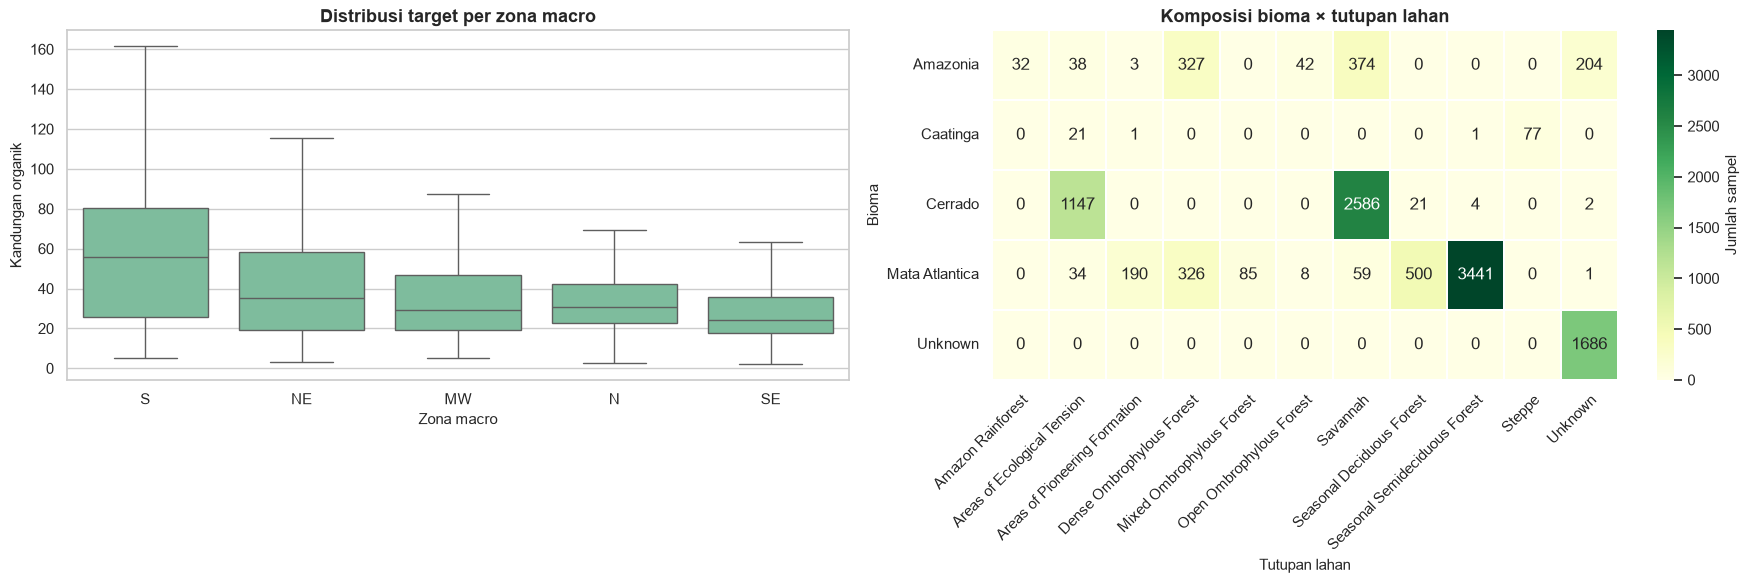

,count,mean,median
land_cover_type,,,
Seasonal Semideciduous Forest,3446,27.6678,22.6524
Savannah,3019,35.0505,30.7426
Unknown,1893,34.1216,27.5065
Areas of Ecological Tension,1240,33.1872,28.0728
Dense Ombrophylous Forest,653,35.4323,27.5065
Seasonal Deciduous Forest,521,69.1805,65.1257
Areas of Pioneering Formation,194,22.8572,22.6524
Mixed Ombrophylous Forest,85,74.2486,77.8434
Steppe,77,45.0983,38.2664


In [10]:
biome_land_mean = train.pivot_table(
    index="biome", columns="land_cover_type", values=TARGET, aggfunc="mean"
)
biome_land_count = train.pivot_table(
    index="biome", columns="land_cover_type", values=TARGET, aggfunc="size",
    fill_value=0
)

_, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(
    data=train, x="geo_zone_macro", y=TARGET,
    order=macro_summary.index, showfliers=False,
    color=LIGHT_GREEN, ax=axes[0]
)
axes[0].set_title("Distribusi target per zona macro")
axes[0].set_xlabel("Zona macro")
axes[0].set_ylabel("Kandungan organik")

sns.heatmap(
    biome_land_count, cmap="YlGn", annot=True, fmt=".0f",
    linewidths=0.3, ax=axes[1], cbar_kws={"label": "Jumlah sampel"}
)
axes[1].set_title("Komposisi bioma × tutupan lahan")
axes[1].set_xlabel("Tutupan lahan")
axes[1].set_ylabel("Bioma")
axes[1].tick_params(axis="y", rotation=0)
axes[1].tick_params(axis="x", rotation=45)
plt.setp(
    axes[1].get_xticklabels(),
    ha="right",
    rotation_mode="anchor",
)
plt.tight_layout()
plt.show()

landcover_summary = (
    train.groupby("land_cover_type")[TARGET]
    .agg(count="size", mean="mean", median="median")
    .sort_values("count", ascending=False)
)
display(landcover_summary)

In [11]:
dominant_biome = train["biome"].value_counts().idxmax()
dominant_cover = train["land_cover_type"].value_counts().idxmax()
highest_macro = macro_summary.index[0]
lowest_macro = macro_summary.index[-1]

display(Markdown(f'''
## Jawaban Soal 3

**Ada perbedaan geografis yang signifikan dan bermakna secara praktis.** Uji Kruskal-Wallis menghasilkan
H = **{kw.statistic:.2f}**, p-value **{kw.pvalue:.2e}**, dan epsilon-squared **{epsilon_squared:.3f}**.
Ukuran efek ini termasuk kecil hingga moderat: perbedaan nyata, tetapi sebagian besar variasi tetap
berada di dalam zona. Zona **{highest_macro}**
memiliki mean tertinggi (**{macro_summary.loc[highest_macro, "mean"]:.2f}**), sedangkan
**{lowest_macro}** terendah (**{macro_summary.loc[lowest_macro, "mean"]:.2f}**).

Post-hoc Holm menunjukkan pasangan mana yang tetap berbeda setelah mengendalikan multiple testing.
Effect size `rank_biserial` memberi konteks karena p-value dapat sangat kecil hanya akibat jumlah sampel
besar.

Berdasarkan **jumlah sampel**, ekosistem dominan adalah bioma **{dominant_biome}** dan tutupan lahan
**{dominant_cover}**. Kelompok besar lain adalah Cerrado/Savannah. Dengan demikian, dataset didominasi
mosaik hutan Atlantik musiman dan savana tropis Brasil, bukan satu tipe ekosistem homogen. Dominan secara
jumlah tidak sama dengan mean target tertinggi: tutupan dengan sampel sedikit dapat memiliki mean tinggi,
sehingga ukuran sampel harus selalu diperiksa.

Secara ekologis, variasi bahan organik dapat dipengaruhi masukan serasah, produktivitas, kelembapan,
musim kering, kebakaran, tekstur tanah, dan penggunaan lahan. Akan tetapi, dataset ini tidak mengukur
seluruh mekanisme tersebut sehingga interpretasinya tetap berupa hipotesis yang konsisten dengan pola.

Referensi konteks: [IBGE — Brazilian biomes](https://www.ibge.gov.br/en/geosciences/environmental-information/vegetation/18391-biomes.html);
[MapBiomas Brasil](https://brasil.mapbiomas.org/en/);
[IPCC Climate Change and Land](https://www.ipcc.ch/srccl/).

**Keterbatasan:** zona adalah kategori, bukan jarak spasial kontinu; komposisi `source_id` juga berbeda
antarwilayah sehingga sebagian perbedaan dapat merefleksikan protokol sampling atau laboratorium.
'''))


## Jawaban Soal 3

**Ada perbedaan geografis yang signifikan dan bermakna secara praktis.** Uji Kruskal-Wallis menghasilkan
H = **747.42**, p-value **1.88e-160**, dan epsilon-squared **0.066**.
Ukuran efek ini termasuk kecil hingga moderat: perbedaan nyata, tetapi sebagian besar variasi tetap
berada di dalam zona. Zona **S**
memiliki mean tertinggi (**57.27**), sedangkan
**SE** terendah (**29.09**).

Post-hoc Holm menunjukkan pasangan mana yang tetap berbeda setelah mengendalikan multiple testing.
Effect size `rank_biserial` memberi konteks karena p-value dapat sangat kecil hanya akibat jumlah sampel
besar.

Berdasarkan **jumlah sampel**, ekosistem dominan adalah bioma **Mata Atlantica** dan tutupan lahan
**Seasonal Semideciduous Forest**. Kelompok besar lain adalah Cerrado/Savannah. Dengan demikian, dataset didominasi
mosaik hutan Atlantik musiman dan savana tropis Brasil, bukan satu tipe ekosistem homogen. Dominan secara
jumlah tidak sama dengan mean target tertinggi: tutupan dengan sampel sedikit dapat memiliki mean tinggi,
sehingga ukuran sampel harus selalu diperiksa.

Secara ekologis, variasi bahan organik dapat dipengaruhi masukan serasah, produktivitas, kelembapan,
musim kering, kebakaran, tekstur tanah, dan penggunaan lahan. Akan tetapi, dataset ini tidak mengukur
seluruh mekanisme tersebut sehingga interpretasinya tetap berupa hipotesis yang konsisten dengan pola.

Referensi konteks: [IBGE — Brazilian biomes](https://www.ibge.gov.br/en/geosciences/environmental-information/vegetation/18391-biomes.html);
[MapBiomas Brasil](https://brasil.mapbiomas.org/en/);
[IPCC Climate Change and Land](https://www.ipcc.ch/srccl/).

**Keterbatasan:** zona adalah kategori, bukan jarak spasial kontinu; komposisi `source_id` juga berbeda
antarwilayah sehingga sebagian perbedaan dapat merefleksikan protokol sampling atau laboratorium.


# Soal 4 — Korelasi antar tingkat wilayah dan rasio rata-rata

> **Apakah ada korelasi kandungan organik tanah antar tingkat wilayah geografis? Berapa rasio
> perbandingan rata-rata kandungan organik antar wilayah tersebut, dan bagaimana ini memengaruhi
> pendekatan pemodelan Anda?**

## Pendekatan dan asumsi

Untuk tiap level wilayah dihitung mean, median, ukuran sampel, dan bootstrap 95% CI. Rasio utama hanya
menggunakan kelompok dengan minimal 20 sampel agar tidak didominasi kelompok sangat kecil.

In [12]:
geo_levels = ["geo_zone_macro", "geo_zone_meso", "geo_zone_micro"]
geo_detail_tables = {}
geo_summary_rows = []
geo_mean_encoded = pd.DataFrame(index=train.index)

for level_index, level in enumerate(geo_levels):
    rows = []
    for group_name, group in train.groupby(level):
        ci_low, ci_high = bootstrap_mean_ci(
            group[TARGET], n_boot=400,
            seed=RANDOM_STATE + level_index + len(group)
        )
        rows.append({
            "group": group_name,
            "count": len(group),
            "mean": group[TARGET].mean(),
            "median": group[TARGET].median(),
            "ci_low": ci_low,
            "ci_high": ci_high,
        })
    detail = pd.DataFrame(rows).sort_values("mean")
    stable = detail.query("count >= 20")
    geo_detail_tables[level] = detail
    geo_summary_rows.append({
        "level": level,
        "n_group": len(detail),
        "n_group_stable": len(stable),
        "min_group": stable.iloc[0]["group"],
        "min_mean": stable.iloc[0]["mean"],
        "max_group": stable.iloc[-1]["group"],
        "max_mean": stable.iloc[-1]["mean"],
        "max_min_ratio": stable.iloc[-1]["mean"] / stable.iloc[0]["mean"],
        "eta_squared": eta_squared(train, level),
    })
    group_means = train.groupby(level)[TARGET].mean()
    geo_mean_encoded[level] = train[level].map(group_means)

geo_summary = pd.DataFrame(geo_summary_rows).set_index("level")
geo_corr = geo_mean_encoded.corr(method="spearman")
display(geo_summary)
display(geo_corr)
display(geo_detail_tables["geo_zone_macro"])

,n_group,n_group_stable,min_group,min_mean,max_group,max_mean,max_min_ratio,eta_squared
level,,,,,,,,
geo_zone_macro,5,5,SE,29.0897,S,57.2668,1.9686,0.1208
geo_zone_meso,23,18,State_18,18.8800,State_03,72.9516,3.8640,0.2747
geo_zone_micro,50,23,Loc_023,10.2256,Loc_005,86.7856,8.4871,0.2734


,geo_zone_macro,geo_zone_meso,geo_zone_micro
geo_zone_macro,1.0000,0.6201,0.3257
geo_zone_meso,0.6201,1.0000,0.5361
geo_zone_micro,0.3257,0.5361,1.0000


,group,count,mean,median,ci_low,ci_high
4,SE,5767,29.0897,24.2705,28.6946,29.5960
1,N,979,34.3947,30.7426,33.2009,35.5898
0,MW,2930,34.5005,29.1245,33.6925,35.2791
2,NE,512,42.3672,35.1922,39.7881,44.8580
3,S,1022,57.2668,55.7897,55.0348,59.3669


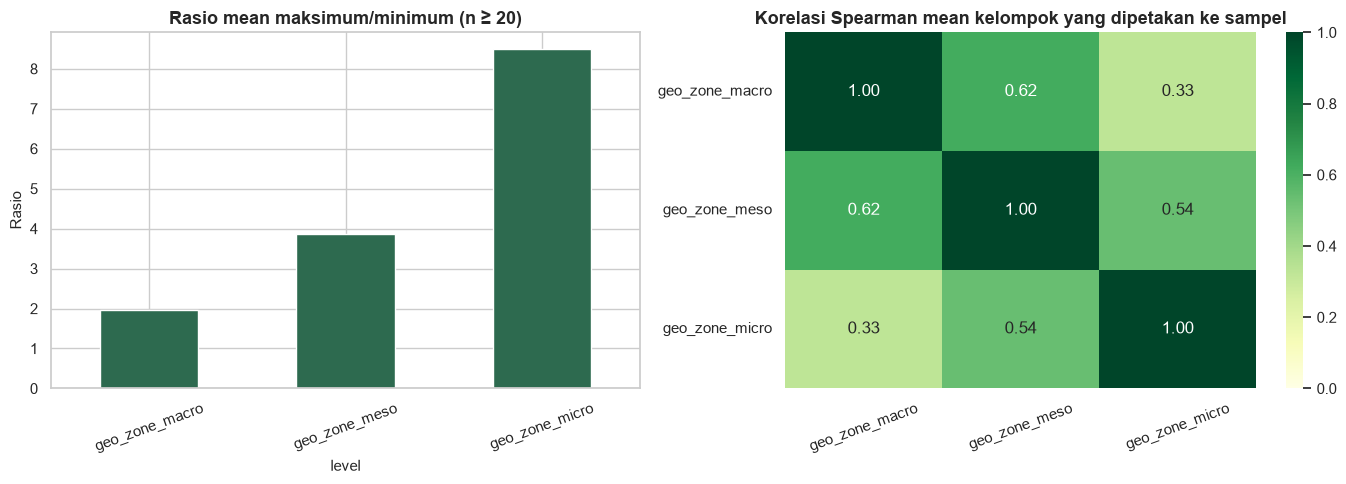

In [13]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))
geo_summary["max_min_ratio"].plot(kind="bar", color=GREEN, ax=axes[0])
axes[0].set_title("Rasio mean maksimum/minimum (n ≥ 20)")
axes[0].set_ylabel("Rasio")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(
    geo_corr, annot=True, fmt=".2f", cmap="YlGn", vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title("Korelasi Spearman mean kelompok yang dipetakan ke sampel")
axes[1].tick_params(axis="y", rotation=0)
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [14]:
display(Markdown(f'''
## Jawaban Soal 4

Ada hubungan hierarkis positif, tetapi tidak sempurna. Korelasi Spearman mean kelompok yang dipetakan
kembali ke sampel adalah:

- macro–meso: **{geo_corr.loc["geo_zone_macro", "geo_zone_meso"]:.2f}**
- meso–micro: **{geo_corr.loc["geo_zone_meso", "geo_zone_micro"]:.2f}**
- macro–micro: **{geo_corr.loc["geo_zone_macro", "geo_zone_micro"]:.2f}**

Untuk kelompok dengan minimal 20 sampel, rasio mean maksimum/minimum adalah
**{geo_summary.loc["geo_zone_macro", "max_min_ratio"]:.2f}x** pada macro,
**{geo_summary.loc["geo_zone_meso", "max_min_ratio"]:.2f}x** pada meso, dan
**{geo_summary.loc["geo_zone_micro", "max_min_ratio"]:.2f}x** pada micro.
Rasio yang makin besar pada resolusi lokal menunjukkan heterogenitas lokal yang tidak tertangkap oleh
zona macro saja.

**Dampak pada modeling:** semua level dipertahankan dan digabungkan dalam fitur hierarki. Model nonlinear
dapat mempelajari interaksi antartingkat, tetapi evaluasi deployment perlu spatial/group validation.
Bootstrap CI dan `count` mencegah mean kelompok kecil dianggap sama kuatnya dengan kelompok besar.

**Keterbatasan:** korelasi ini adalah korelasi mean kategori yang dipetakan ke baris, bukan Moran's I atau
semivariogram. Koordinat banyak yang hilang, sehingga autokorelasi spasial kontinu tidak dapat diuji
secara lengkap.
'''))


## Jawaban Soal 4

Ada hubungan hierarkis positif, tetapi tidak sempurna. Korelasi Spearman mean kelompok yang dipetakan
kembali ke sampel adalah:

- macro–meso: **0.62**
- meso–micro: **0.54**
- macro–micro: **0.33**

Untuk kelompok dengan minimal 20 sampel, rasio mean maksimum/minimum adalah
**1.97x** pada macro,
**3.86x** pada meso, dan
**8.49x** pada micro.
Rasio yang makin besar pada resolusi lokal menunjukkan heterogenitas lokal yang tidak tertangkap oleh
zona macro saja.

**Dampak pada modeling:** semua level dipertahankan dan digabungkan dalam fitur hierarki. Model nonlinear
dapat mempelajari interaksi antartingkat, tetapi evaluasi deployment perlu spatial/group validation.
Bootstrap CI dan `count` mencegah mean kelompok kecil dianggap sama kuatnya dengan kelompok besar.

**Keterbatasan:** korelasi ini adalah korelasi mean kategori yang dipetakan ke baris, bukan Moran's I atau
semivariogram. Koordinat banyak yang hilang, sehingga autokorelasi spasial kontinu tidak dapat diuji
secara lengkap.


# Soal 5a — Kondisi acidity dan kapasitas tukar kation

> **Berapa rata-rata kandungan organik tanah dari tiap ekosistem ketika tingkat keasaman tanah berada
> di bawah persentil 25 dan kapasitas tukar kation berada di bawah rata-rata? Apa insight yang bisa
> didapat dari hal ini?**

## Pendekatan dan asumsi

P25 acidity dan mean KTK dihitung dari nilai nonmissing. Kelompok ekosistem menggunakan kolom `biome`.
Selain mean, ditampilkan median, standard deviation, dan bootstrap 95% CI.

P25 acidity index = 12.8805
Mean cation exchange capacity = 169.1421
Jumlah sampel hasil filter = 388


,biome,count,mean,median,std,ci_low,ci_high,cukup_stabil_n_ge_20
4,Unknown,1,43.6868,43.6868,NaN,43.6868,43.6868,False
0,Amazonia,197,27.6124,27.5065,6.7311,26.5948,28.5993,True
2,Cerrado,2,24.2705,24.2705,0.0000,24.2705,24.2705,False
3,Mata Atlantica,186,21.3180,21.0344,10.0405,20.0135,22.8990,True
1,Caatinga,2,19.9827,19.9827,1.2585,19.0928,20.8726,False


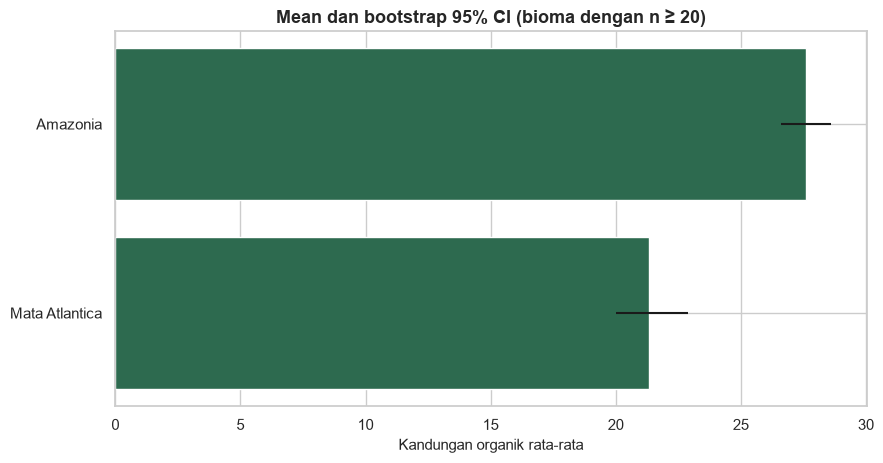

In [15]:
acidity_p25 = train["property_acidity_index"].quantile(0.25)
cec_mean = train["cation_exchange_capacity"].mean()
subset_5a = train[
    (train["property_acidity_index"] < acidity_p25)
    & (train["cation_exchange_capacity"] < cec_mean)
].copy()

q5a_rows = []
for index, (biome, group) in enumerate(subset_5a.groupby("biome")):
    ci_low, ci_high = bootstrap_mean_ci(
        group[TARGET], n_boot=1000, seed=RANDOM_STATE + index
    )
    q5a_rows.append({
        "biome": biome,
        "count": len(group),
        "mean": group[TARGET].mean(),
        "median": group[TARGET].median(),
        "std": group[TARGET].std(),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cukup_stabil_n_ge_20": len(group) >= 20,
    })
q5a = pd.DataFrame(q5a_rows).sort_values("mean", ascending=False)

print(f"P25 acidity index = {acidity_p25:.4f}")
print(f"Mean cation exchange capacity = {cec_mean:.4f}")
print(f"Jumlah sampel hasil filter = {len(subset_5a)}")
display(q5a)

stable_q5a = q5a.query("count >= 20").sort_values("mean")
plt.figure(figsize=(9, 4.8))
xerr = np.vstack([
    stable_q5a["mean"] - stable_q5a["ci_low"],
    stable_q5a["ci_high"] - stable_q5a["mean"],
])
plt.barh(stable_q5a["biome"], stable_q5a["mean"], color=GREEN, xerr=xerr)
plt.title("Mean dan bootstrap 95% CI (bioma dengan n ≥ 20)")
plt.xlabel("Kandungan organik rata-rata")
plt.tight_layout()
plt.show()

In [16]:
stable_text = "; ".join(
    f"{row.biome}: mean {row.mean:.2f} (n={int(row.count)})"
    for row in stable_q5a.itertuples()
)
display(Markdown(f'''
## Jawaban Soal 5a

Ambang filter adalah acidity index < **{acidity_p25:.4f}** dan KTK <
**{cec_mean:.4f}**. Total sampel yang memenuhi kedua syarat adalah **{len(subset_5a)}**.

Untuk kelompok dengan ukuran memadai: **{stable_text}**. Bioma dengan n sangat kecil tetap ditampilkan
pada tabel, tetapi tidak dijadikan dasar generalisasi karena confidence interval atau mean-nya tidak
stabil.

**Insight:** acidity rendah dan KTK di bawah rata-rata tidak menghasilkan satu level kandungan organik
yang seragam. Perbedaan antarekosistem tetap terlihat, sehingga kondisi kimia ini perlu diinterpretasikan
bersama bioma, tekstur, tutupan lahan, dan sumber data. Mean juga perlu didampingi median dan CI karena
target right-skewed.

**Keterbatasan:** filter complete-case membuat hasil hanya mewakili sampel yang memiliki kedua pengukuran.
Dengan missingness acidity yang tinggi, subset ini dapat memiliki selection bias.
'''))


## Jawaban Soal 5a

Ambang filter adalah acidity index < **12.8805** dan KTK <
**169.1421**. Total sampel yang memenuhi kedua syarat adalah **388**.

Untuk kelompok dengan ukuran memadai: **Mata Atlantica: mean 21.32 (n=186); Amazonia: mean 27.61 (n=197)**. Bioma dengan n sangat kecil tetap ditampilkan
pada tabel, tetapi tidak dijadikan dasar generalisasi karena confidence interval atau mean-nya tidak
stabil.

**Insight:** acidity rendah dan KTK di bawah rata-rata tidak menghasilkan satu level kandungan organik
yang seragam. Perbedaan antarekosistem tetap terlihat, sehingga kondisi kimia ini perlu diinterpretasikan
bersama bioma, tekstur, tutupan lahan, dan sumber data. Mean juga perlu didampingi median dan CI karena
target right-skewed.

**Keterbatasan:** filter complete-case membuat hasil hanya mewakili sampel yang memiliki kedua pengukuran.
Dengan missingness acidity yang tinggi, subset ini dapat memiliki selection bias.


# Soal 5b — Outlier kombinasi tutupan lahan dan wilayah

> **Apakah ada kombinasi jenis tutupan lahan dan wilayah geografis tertentu yang memiliki nilai
> kandungan organik yang dapat dianggap sebagai outlier? Jelaskan justifikasi Anda!**

## Pendekatan dan asumsi

Outlier dihitung **di dalam setiap kombinasi** `land_cover_type × geo_zone_macro` dengan minimal 20
sampel. Definisi utama menggunakan IQR; sensitivity check menggunakan robust z-score berbasis MAD.

In [17]:
combo = train.groupby(["land_cover_type", "geo_zone_macro"])[TARGET].agg(
    n="size",
    mean="mean",
    median="median",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    mad=lambda s: stats.median_abs_deviation(s, scale=1, nan_policy="omit"),
).reset_index()
combo["iqr"] = combo["q3"] - combo["q1"]
combo["lower_iqr"] = combo["q1"] - 1.5 * combo["iqr"]
combo["upper_iqr"] = combo["q3"] + 1.5 * combo["iqr"]

outlier_data = train.merge(
    combo, on=["land_cover_type", "geo_zone_macro"], how="left"
)
outlier_data["outlier_iqr"] = (
    (outlier_data[TARGET] < outlier_data["lower_iqr"])
    | (outlier_data[TARGET] > outlier_data["upper_iqr"])
)
outlier_data["robust_z"] = np.where(
    outlier_data["mad"] > 0,
    0.6745 * (outlier_data[TARGET] - outlier_data["median"])
    / outlier_data["mad"],
    0,
)
outlier_data["outlier_mad"] = outlier_data["robust_z"].abs() > 3.5

outlier_summary = (
    outlier_data.groupby(["land_cover_type", "geo_zone_macro"])
    .agg(
        n=(TARGET, "size"),
        mean_target=(TARGET, "mean"),
        outlier_iqr=("outlier_iqr", "sum"),
        outlier_mad=("outlier_mad", "sum"),
        max_target=(TARGET, "max"),
    )
    .reset_index()
)
outlier_summary["iqr_rate"] = outlier_summary["outlier_iqr"] / outlier_summary["n"]
outlier_summary["mad_rate"] = outlier_summary["outlier_mad"] / outlier_summary["n"]
outlier_summary["kombinasi"] = (
    outlier_summary["land_cover_type"] + " | "
    + outlier_summary["geo_zone_macro"]
)
reliable_outliers = (
    outlier_summary.query("n >= 20")
    .sort_values(["iqr_rate", "outlier_iqr"], ascending=False)
)
display(reliable_outliers.head(15))

,land_cover_type,geo_zone_macro,n,mean_target,outlier_iqr,outlier_mad,max_target,iqr_rate,mad_rate,kombinasi
0,Amazon Rainforest,NE,32,10.2256,4,4,25.6188,0.1250,0.1250,Amazon Rainforest | NE
25,Seasonal Semideciduous Forest,SE,3150,26.0721,235,187,155.3309,0.0746,0.0594,Seasonal Semideciduous Forest | SE
27,Unknown,MW,541,40.8451,38,28,177.0610,0.0702,0.0518,Unknown | MW
2,Areas of Ecological Tension,N,38,56.7401,2,0,131.0604,0.0526,0.0000,Areas of Ecological Tension | N
26,Steppe,NE,77,45.0983,3,2,185.9440,0.0390,0.0260,Steppe | NE
21,Seasonal Deciduous Forest,S,487,71.0500,18,3,189.7949,0.0370,0.0062,Seasonal Deciduous Forest | S
18,Savannah,N,374,29.9321,13,8,90.6097,0.0348,0.0214,Savannah | N
1,Areas of Ecological Tension,MW,1028,30.3010,31,13,88.6680,0.0302,0.0126,Areas of Ecological Tension | MW
5,Areas of Ecological Tension,SE,145,41.7878,4,8,135.1055,0.0276,0.0552,Areas of Ecological Tension | SE
20,Savannah,SE,1709,35.3806,45,26,181.2194,0.0263,0.0152,Savannah | SE


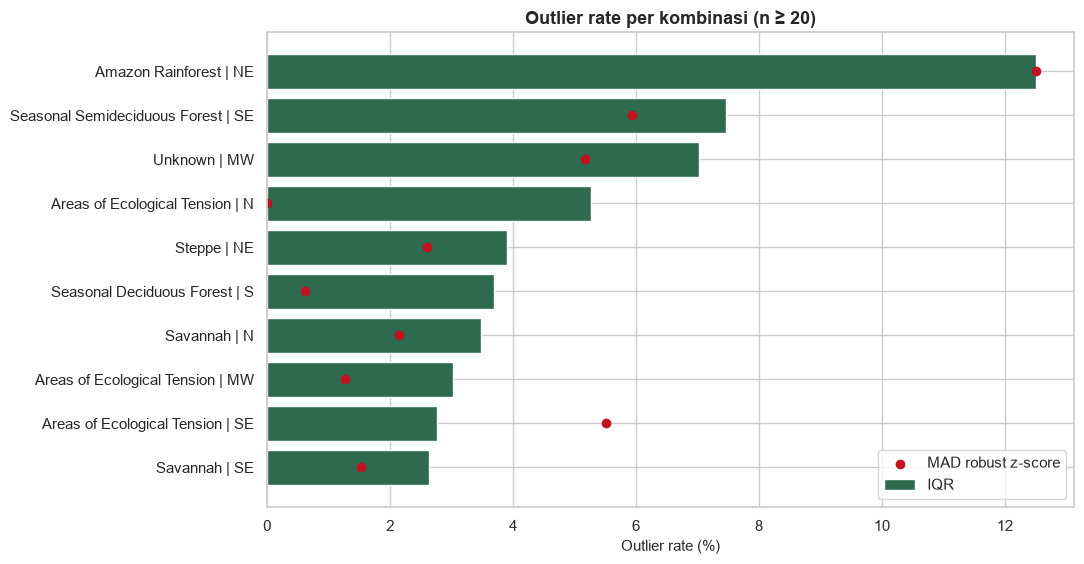

,sample_id,land_cover_type,geo_zone_macro,property_organic_content,lower_iqr,upper_iqr,robust_z
1453,train_01454,Dense Ombrophylous Forest,NE,193.6782,-69.0737,155.2500,4.7283
10245,train_10246,Seasonal Deciduous Forest,S,189.7949,-15.1326,151.6863,3.8915
6873,train_06874,Steppe,NE,185.9440,-14.5623,98.0526,7.4711
7562,train_07563,Seasonal Deciduous Forest,S,183.4037,-15.1326,151.6863,3.6881
669,train_00670,Seasonal Deciduous Forest,S,183.4037,-15.1326,151.6863,3.6881
9218,train_09219,Savannah,SE,181.2194,-12.9442,80.2543,9.3323
4605,train_04606,Unknown,MW,177.0610,-33.1696,102.7449,6.7028
6469,train_06470,Unknown,MW,177.0610,-33.1696,102.7449,6.7028
587,train_00588,Unknown,MW,177.0610,-33.1696,102.7449,6.7028
10602,train_10603,Unknown,MW,177.0610,-33.1696,102.7449,6.7028


In [18]:
top_outliers = reliable_outliers.head(10).sort_values("iqr_rate")
plt.figure(figsize=(11, 5.8))
plt.barh(
    top_outliers["kombinasi"], top_outliers["iqr_rate"] * 100,
    color=GREEN, label="IQR"
)
plt.scatter(
    top_outliers["mad_rate"] * 100,
    top_outliers["kombinasi"],
    color=RED, label="MAD robust z-score"
)
plt.title("Outlier rate per kombinasi (n ≥ 20)")
plt.xlabel("Outlier rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

individual_outliers = (
    outlier_data.loc[
        outlier_data["outlier_iqr"] & (outlier_data["n"] >= 20),
        ["sample_id", "land_cover_type", "geo_zone_macro", TARGET,
         "lower_iqr", "upper_iqr", "robust_z"]
    ]
    .sort_values(TARGET, ascending=False)
    .head(15)
)
display(individual_outliers)

In [19]:
top_combo = reliable_outliers.iloc[0]
display(Markdown(f'''
## Jawaban Soal 5b

Ya. Dengan aturan IQR di dalam kelompok dan minimum 20 sampel, kombinasi dengan proporsi outlier
tertinggi adalah **{top_combo["kombinasi"]}**, yaitu
**{top_combo["iqr_rate"] * 100:.1f}%** ({int(top_combo["outlier_iqr"])} dari
{int(top_combo["n"])} sampel). Tabel dan grafik menunjukkan kombinasi lain serta perbandingan dengan
robust z-score berbasis MAD.

**Justifikasi:** batas dibuat per kombinasi agar kelompok yang secara alami memiliki mean atau sebaran
tinggi tidak ditandai hanya karena berbeda dari populasi global. Minimum 20 sampel mencegah kuartil
kelompok sangat kecil menjadi tidak stabil. Kesepakatan IQR dan MAD memperkuat indikasi, sedangkan
ketidaksepakatan menunjukkan hasil sensitif terhadap definisi outlier.

Outlier tidak otomatis dihapus. Nilai ekstrem dapat merepresentasikan kondisi mikro-lokasi, tanah
organik, drainase, pengelolaan, atau perbedaan laboratorium. Langkah yang tepat adalah pemeriksaan
metadata, analisis residual, dan robust validation.

**Keterbatasan:** IQR/MAD bersifat univariat dan tidak menilai apakah kombinasi fitur lain membuat nilai
tersebut sebenarnya masuk akal.
'''))


## Jawaban Soal 5b

Ya. Dengan aturan IQR di dalam kelompok dan minimum 20 sampel, kombinasi dengan proporsi outlier
tertinggi adalah **Amazon Rainforest | NE**, yaitu
**12.5%** (4 dari
32 sampel). Tabel dan grafik menunjukkan kombinasi lain serta perbandingan dengan
robust z-score berbasis MAD.

**Justifikasi:** batas dibuat per kombinasi agar kelompok yang secara alami memiliki mean atau sebaran
tinggi tidak ditandai hanya karena berbeda dari populasi global. Minimum 20 sampel mencegah kuartil
kelompok sangat kecil menjadi tidak stabil. Kesepakatan IQR dan MAD memperkuat indikasi, sedangkan
ketidaksepakatan menunjukkan hasil sensitif terhadap definisi outlier.

Outlier tidak otomatis dihapus. Nilai ekstrem dapat merepresentasikan kondisi mikro-lokasi, tanah
organik, drainase, pengelolaan, atau perbedaan laboratorium. Langkah yang tepat adalah pemeriksaan
metadata, analisis residual, dan robust validation.

**Keterbatasan:** IQR/MAD bersifat univariat dan tidak menilai apakah kombinasi fitur lain membuat nilai
tersebut sebenarnya masuk akal.


# Soal 6 — Korelasi tinggi dan multicollinearity

> **Apakah ada pasangan variabel yang berkorelasi tinggi? Apakah ada efek multicollinearity yang perlu
> diatasi dalam modeling?**

## Pendekatan dan asumsi

Spearman digunakan karena distribusi tidak normal dan hubungan dapat monotonic nonlinear. VIF dihitung
pada fitur tanah utama setelah median imputation dan standardization.

,,spearman_r,abs_r
property_particle_coarse,property_particle_fine,-0.9147,0.9147
cation_Ca,cation_Mg,0.8582,0.8582
property_acidity_index,cation_Ca,0.7214,0.7214


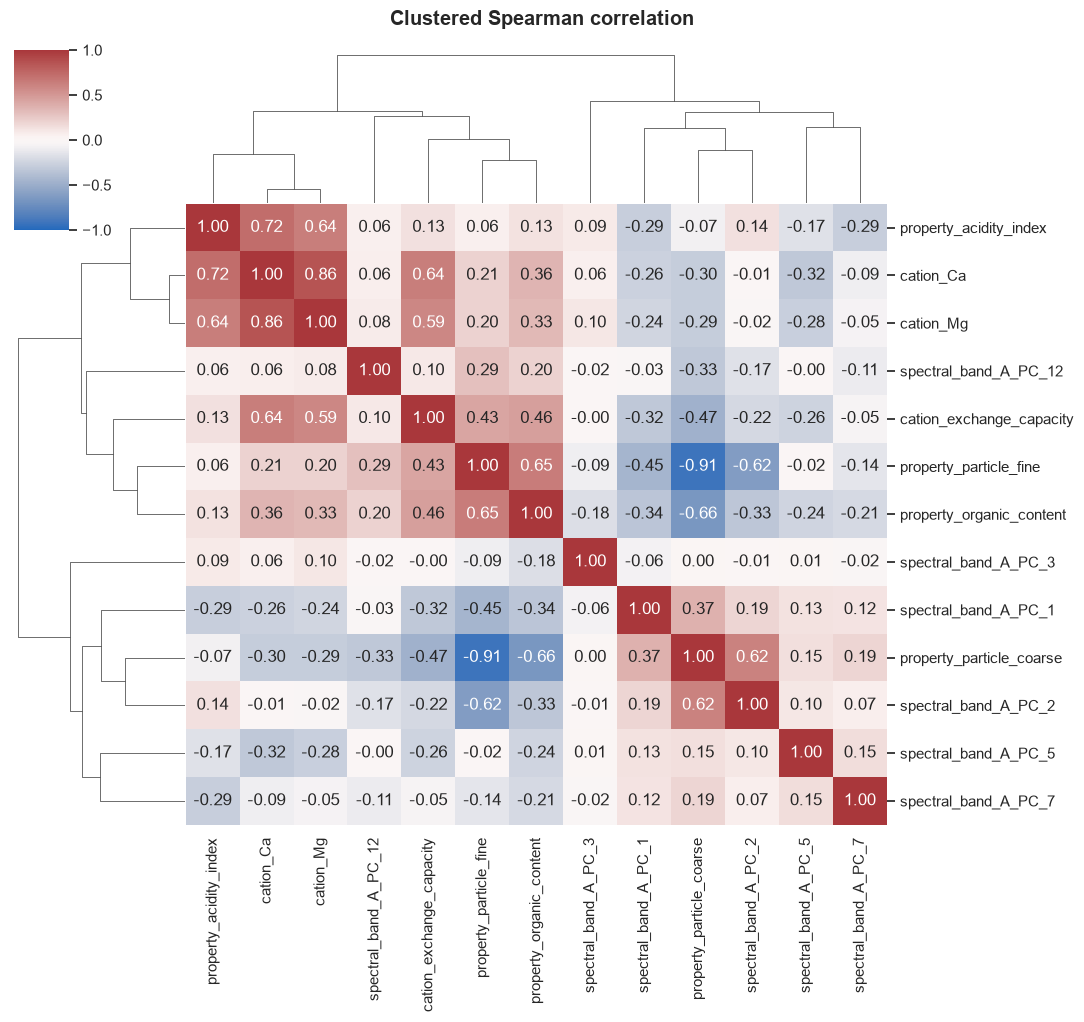

In [20]:
numeric = train.select_dtypes(include=np.number)
spearman = numeric.corr(method="spearman")
upper = np.triu(np.ones(spearman.shape), k=1).astype(bool)
corr_pairs = spearman.where(upper).stack().rename("spearman_r").to_frame()
corr_pairs["abs_r"] = corr_pairs["spearman_r"].abs()
high_corr_pairs = corr_pairs.query("abs_r >= 0.70").sort_values(
    "abs_r", ascending=False
)
display(high_corr_pairs)

selected_corr_features = [
    "property_particle_coarse", "property_particle_fine",
    "property_acidity_index", "cation_Ca", "cation_Mg",
    "cation_exchange_capacity", "spectral_band_A_PC_1",
    "spectral_band_A_PC_2", "spectral_band_A_PC_3",
    "spectral_band_A_PC_5", "spectral_band_A_PC_7",
    "spectral_band_A_PC_12", TARGET,
]
cluster = sns.clustermap(
    train[selected_corr_features].corr(method="spearman"),
    cmap="vlag", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", figsize=(11, 10)
)
cluster.fig.suptitle("Clustered Spearman correlation", y=1.02, fontweight="bold")
plt.show()

In [21]:
vif_cols = [
    "property_particle_coarse", "property_particle_fine",
    "property_acidity_index", "cation_Ca", "cation_Mg",
    "cation_exchange_capacity",
]
vif_matrix = SimpleImputer(strategy="median").fit_transform(train[vif_cols])
vif_matrix = StandardScaler().fit_transform(vif_matrix)

vif_rows = []
for i, feature in enumerate(vif_cols):
    other = np.arange(len(vif_cols)) != i
    feature_r2 = LinearRegression().fit(
        vif_matrix[:, other], vif_matrix[:, i]
    ).score(vif_matrix[:, other], vif_matrix[:, i])
    vif_rows.append({
        "feature": feature,
        "VIF": 1 / (1 - feature_r2),
    })
vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
condition_number = np.linalg.cond(vif_matrix)
display(vif_table)
print(f"Condition number = {condition_number:.3f}")

,feature,VIF
0,property_particle_coarse,6.0290
1,property_particle_fine,5.7258
3,cation_Ca,2.9186
4,cation_Mg,2.4334
5,cation_exchange_capacity,1.6396
2,property_acidity_index,1.0850


Condition number = 5.568


In [22]:
strongest_pair = high_corr_pairs.iloc[0]
display(Markdown(f'''
## Jawaban Soal 6

Ada pasangan dengan korelasi tinggi. Pasangan terkuat adalah
`{high_corr_pairs.index[0][0]}` dan `{high_corr_pairs.index[0][1]}` dengan Spearman
**{strongest_pair["spearman_r"]:.2f}**. Korelasi Ca–Mg juga tinggi. VIF tertinggi adalah
**{vif_table.iloc[0]["VIF"]:.2f}** pada `{vif_table.iloc[0]["feature"]}`.

Ini merupakan multikolinearitas moderat yang penting untuk regresi linear karena dapat membuat
koefisien tidak stabil dan sulit ditafsirkan. PLS menjadi pembanding relevan karena membentuk komponen
laten dari prediktor berkorelasi. CatBoost tidak membutuhkan inversi matriks dan lebih tahan terhadap
multikolinearitas, sehingga fitur tidak harus dibuang hanya berdasarkan VIF.

Dalam model utama, fraksi kasar/halus tetap dipertahankan dan ditambah fitur komposisional seperti
`fine_fraction`. Konsekuensinya, feature importance tidak boleh dibaca sebagai efek kausal individual
karena importance dapat terbagi di antara fitur yang saling berkorelasi.

Referensi PLS: Wold, Sjöström, & Eriksson (2001),
[PLS-regression: a basic tool of chemometrics](https://doi.org/10.1016/S0169-7439(01)00155-1).

**Keterbatasan:** VIF dihitung pada subset fitur tanah agar dapat ditafsirkan; VIF untuk seluruh dummy
kategori dan komponen engineered tidak akan memberi ringkasan yang stabil atau ringkas.
'''))


## Jawaban Soal 6

Ada pasangan dengan korelasi tinggi. Pasangan terkuat adalah
`property_particle_coarse` dan `property_particle_fine` dengan Spearman
**-0.91**. Korelasi Ca–Mg juga tinggi. VIF tertinggi adalah
**6.03** pada `property_particle_coarse`.

Ini merupakan multikolinearitas moderat yang penting untuk regresi linear karena dapat membuat
koefisien tidak stabil dan sulit ditafsirkan. PLS menjadi pembanding relevan karena membentuk komponen
laten dari prediktor berkorelasi. CatBoost tidak membutuhkan inversi matriks dan lebih tahan terhadap
multikolinearitas, sehingga fitur tidak harus dibuang hanya berdasarkan VIF.

Dalam model utama, fraksi kasar/halus tetap dipertahankan dan ditambah fitur komposisional seperti
`fine_fraction`. Konsekuensinya, feature importance tidak boleh dibaca sebagai efek kausal individual
karena importance dapat terbagi di antara fitur yang saling berkorelasi.

Referensi PLS: Wold, Sjöström, & Eriksson (2001),
[PLS-regression: a basic tool of chemometrics](https://doi.org/10.1016/S0169-7439(01)00155-1).

**Keterbatasan:** VIF dihitung pada subset fitur tanah agar dapat ditafsirkan; VIF untuk seluruh dummy
kategori dan komponen engineered tidak akan memberi ringkasan yang stabil atau ringkas.


# Soal 7 - Feature engineering

> **Fitur baru apa saja yang Anda buat melalui proses feature engineering? Jelaskan bagaimana fitur
> tersebut meningkatkan pemahaman model terhadap pola kandungan organik tanah!**

## Pendekatan dan asumsi

Manfaat fitur diuji melalui ablation study bertahap pada split yang sama. Selain itu, model penuh
dibandingkan dengan versi tanpa `source_id` untuk mengukur ketergantungan pada identitas sumber.
Feature set di sini diselaraskan dengan `main.ipynb` agar interpretasi research question konsisten
dengan pipeline submission terbaru.

In [23]:
split_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
idx_train, idx_valid = train_test_split(
    np.arange(len(train)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=split_bins,
)

stage_labels = {
    "raw": "Raw",
    "missingness": "+ Missingness",
    "spectral": "+ Spectral summaries",
    "soil": "+ Soil ratios",
    "geographic": "+ Geo/ecology interactions",
    "full": "+ Coordinate grids (full)",
}
ablation_rows = []

for stage, label in stage_labels.items():
    X_stage, cat_stage = make_features(train, stage=stage)
    stage_model = CatBoostRegressor(
        iterations=400,
        depth=6,
        learning_rate=0.06,
        l2_leaf_reg=8,
        random_strength=1,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )
    stage_model.fit(
        X_stage.iloc[idx_train], y.iloc[idx_train],
        cat_features=cat_stage,
        eval_set=(X_stage.iloc[idx_valid], y.iloc[idx_valid]),
        early_stopping_rounds=70,
        verbose=False,
    )
    pred = stage_model.predict(X_stage.iloc[idx_valid])
    ablation_rows.append({
        "stage": stage,
        "label": label,
        "n_features": X_stage.shape[1],
        "best_iteration": stage_model.get_best_iteration(),
        "RMSE": root_mean_squared_error(y.iloc[idx_valid], pred),
        "MAE": mean_absolute_error(y.iloc[idx_valid], pred),
    })
    print(f"Ablation {stage} selesai.")

X_no_source, cat_no_source = make_features(
    train, stage="full", drop_source=True
)
no_source_model = CatBoostRegressor(
    iterations=400, depth=6, learning_rate=0.06, l2_leaf_reg=8,
    random_strength=1, loss_function="RMSE", random_seed=RANDOM_STATE,
    verbose=False, allow_writing_files=False, thread_count=-1,
)
no_source_model.fit(
    X_no_source.iloc[idx_train], y.iloc[idx_train],
    cat_features=cat_no_source,
    eval_set=(X_no_source.iloc[idx_valid], y.iloc[idx_valid]),
    early_stopping_rounds=70, verbose=False,
)
no_source_pred = no_source_model.predict(X_no_source.iloc[idx_valid])

ablation = pd.DataFrame(ablation_rows)
raw_rmse = ablation.loc[ablation["stage"] == "raw", "RMSE"].iloc[0]
ablation["RMSE_improvement_vs_raw"] = raw_rmse - ablation["RMSE"]
source_sensitivity = pd.Series({
    "full_RMSE": ablation.loc[ablation["stage"] == "full", "RMSE"].iloc[0],
    "without_source_RMSE": root_mean_squared_error(
        y.iloc[idx_valid], no_source_pred
    ),
})
source_sensitivity["delta_without_source"] = (
    source_sensitivity["without_source_RMSE"]
    - source_sensitivity["full_RMSE"]
)
display(ablation)
display(source_sensitivity.to_frame("nilai"))

Ablation raw selesai.


Ablation missingness selesai.


Ablation spectral selesai.


Ablation soil selesai.


Ablation geographic selesai.


Ablation full selesai.


,stage,label,n_features,best_iteration,RMSE,MAE,RMSE_improvement_vs_raw
0,raw,Raw,50,399,12.0848,7.6572,0.0000
1,missingness,+ Missingness,55,399,12.0946,7.6025,-0.0099
2,spectral,+ Spectral summaries,67,399,12.1734,7.6775,-0.0886
3,soil,+ Soil ratios,74,399,12.0075,7.5725,0.0773
4,geographic,+ Geo/ecology interactions,79,399,11.9618,7.5927,0.1230
5,full,+ Coordinate grids (full),81,398,12.1696,7.6612,-0.0848


,nilai
full_RMSE,12.1696
without_source_RMSE,12.2900
delta_without_source,0.1204


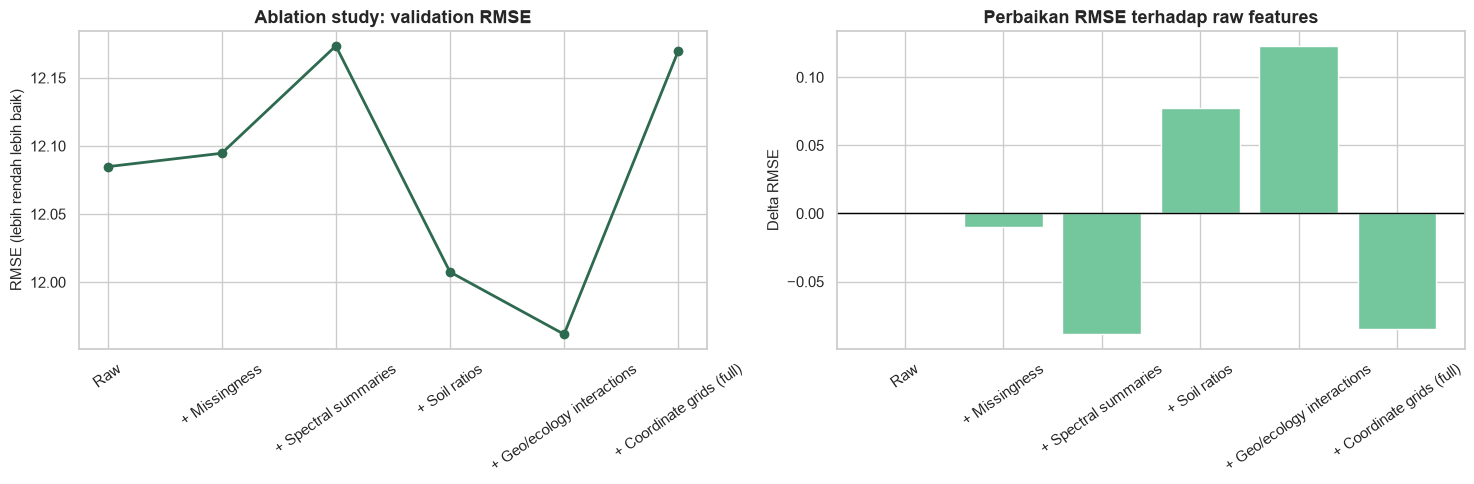

In [24]:
_, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(
    ablation["label"], ablation["RMSE"], marker="o", color=GREEN, lw=2
)
axes[0].set_title("Ablation study: validation RMSE")
axes[0].set_ylabel("RMSE (lebih rendah lebih baik)")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(
    ablation["label"], ablation["RMSE_improvement_vs_raw"],
    color=LIGHT_GREEN
)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Perbaikan RMSE terhadap raw features")
axes[1].set_ylabel("Delta RMSE")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

In [25]:
best_stage = ablation.sort_values("RMSE").iloc[0]
display(Markdown(f'''
## Jawaban Soal 7

Fitur baru dibagi menjadi:

1. **Missingness:** jumlah nilai hilang, ketersediaan band B aktual, jumlah missing band B, dan
   ketersediaan koordinat.
2. **Ringkasan spektral:** mean, standard deviation, L2 norm, maximum absolute component,
   absolute-sum, dan jumlah komponen positif untuk band A/B.
3. **Tekstur dan kimia:** total partikel, fine fraction, coarse/fine ratio, jumlah kation basa,
   rasio Ca/Mg, rasio kation/KTK, dan log KTK.
4. **Interaksi geografis/ekologis:** hierarchy macro-meso-micro, biome-land cover, source-band B,
   macro-biome, dan macro-land cover.
5. **Grid koordinat:** latitude dan longitude dibulatkan 0,1 derajat.

Stage terbaik pada holdout yang sama adalah **{best_stage["label"]}** dengan RMSE
**{best_stage["RMSE"]:.3f}**, dibanding raw RMSE **{raw_rmse:.3f}**. Ablation memperlihatkan apakah
penambahan kelompok fitur benar-benar meningkatkan prediksi, bukan hanya terdengar masuk akal.

Menghapus `source_id` mengubah RMSE sebesar **{source_sensitivity["delta_without_source"]:.3f}**.
Jika performa memburuk cukup besar, model menggunakan informasi domain/laboratorium; hal ini berguna
untuk kompetisi tetapi harus diaudit pada sumber baru melalui GroupKFold.

**Bagaimana fitur membantu pemahaman model:** ringkasan spektral menangkap energi dan penyebaran sinyal;
rasio tanah merepresentasikan komposisi; interaksi kategori menangkap konteks lokal; indikator missingness
memberi informasi tentang proses pengukuran. Fitur macro-biome dan macro-land cover membantu model
membedakan pola SOC yang sama-sama ekologis tetapi berbeda konteks wilayah.

**Keterbatasan:** ablation satu holdout lebih cepat dan konsisten, tetapi memiliki uncertainty lebih besar
daripada nested cross-validation. Hasilnya digunakan sebagai bukti arah, bukan estimasi final tunggal.
'''))


## Jawaban Soal 7

Fitur baru dibagi menjadi:

1. **Missingness:** jumlah nilai hilang, ketersediaan band B aktual, jumlah missing band B, dan
   ketersediaan koordinat.
2. **Ringkasan spektral:** mean, standard deviation, L2 norm, maximum absolute component,
   absolute-sum, dan jumlah komponen positif untuk band A/B.
3. **Tekstur dan kimia:** total partikel, fine fraction, coarse/fine ratio, jumlah kation basa,
   rasio Ca/Mg, rasio kation/KTK, dan log KTK.
4. **Interaksi geografis/ekologis:** hierarchy macro-meso-micro, biome-land cover, source-band B,
   macro-biome, dan macro-land cover.
5. **Grid koordinat:** latitude dan longitude dibulatkan 0,1 derajat.

Stage terbaik pada holdout yang sama adalah **+ Geo/ecology interactions** dengan RMSE
**11.962**, dibanding raw RMSE **12.085**. Ablation memperlihatkan apakah
penambahan kelompok fitur benar-benar meningkatkan prediksi, bukan hanya terdengar masuk akal.

Menghapus `source_id` mengubah RMSE sebesar **0.120**.
Jika performa memburuk cukup besar, model menggunakan informasi domain/laboratorium; hal ini berguna
untuk kompetisi tetapi harus diaudit pada sumber baru melalui GroupKFold.

**Bagaimana fitur membantu pemahaman model:** ringkasan spektral menangkap energi dan penyebaran sinyal;
rasio tanah merepresentasikan komposisi; interaksi kategori menangkap konteks lokal; indikator missingness
memberi informasi tentang proses pengukuran. Fitur macro-biome dan macro-land cover membantu model
membedakan pola SOC yang sama-sama ekologis tetapi berbeda konteks wilayah.

**Keterbatasan:** ablation satu holdout lebih cepat dan konsisten, tetapi memiliki uncertainty lebih besar
daripada nested cross-validation. Hasilnya digunakan sebagai bukti arah, bukan estimasi final tunggal.


# Soal 8 - Model prediksi dan alasan pemilihan

> **Jelaskan model yang Anda gunakan dalam memprediksi kandungan organik tanah! Mengapa Anda memilih
> model tersebut dibanding alternatif lain, khususnya dalam konteks data yang memiliki representasi
> spektral?**

## Pendekatan dan asumsi

Model dibandingkan pada lima fold yang sama:

- Dummy median sebagai baseline minimum;
- PLSRegression sebagai baseline chemometrics untuk fitur numerik/spektral berkorelasi;
- CatBoost sebagai model gradient boosting yang kuat untuk fitur kategorikal dan missing values;
- ExtraTrees sebagai ensemble nonlinear berbasis randomization;
- final weighted blend 47,5% CatBoost dan 52,5% ExtraTrees sebagai model submission terbaru.

In [26]:
model_oof = {
    "Dummy": np.zeros(len(train)),
    "PLS": np.zeros(len(train)),
    "CatBoost": cat_oof.copy(),
    "ExtraTrees": et_oof.copy(),
    "Final blend": oof_pred.copy(),
}
model_times = {
    "Dummy": [],
    "PLS": [],
    "CatBoost": catboost_fold_times.copy(),
    "ExtraTrees": extratrees_fold_times.copy(),
    "Final blend": [
        cat_time + et_time
        for cat_time, et_time in zip(catboost_fold_times, extratrees_fold_times)
    ],
}

for fold, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
    dummy = DummyRegressor(strategy="median")
    started = time.perf_counter()
    dummy.fit(np.zeros((len(train_idx), 1)), y.iloc[train_idx])
    model_oof["Dummy"][valid_idx] = dummy.predict(
        np.zeros((len(valid_idx), 1))
    )
    model_times["Dummy"].append(time.perf_counter() - started)

    pls = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=15, scale=False, max_iter=500)),
    ])
    started = time.perf_counter()
    pls.fit(X_full.iloc[train_idx][numeric_full_cols], y.iloc[train_idx])
    model_oof["PLS"][valid_idx] = np.asarray(
        pls.predict(X_full.iloc[valid_idx][numeric_full_cols])
    ).ravel()
    model_times["PLS"].append(time.perf_counter() - started)
    print(f"Benchmark baseline fold {fold} selesai.")

benchmark_fold_rows = []
for fold, (_, valid_idx) in enumerate(cv_splits, start=1):
    for model_name, pred in model_oof.items():
        fold_result = regression_metrics(y.iloc[valid_idx], pred[valid_idx])
        benchmark_fold_rows.append({
            "fold": fold,
            "model": model_name,
            **fold_result,
            "train_seconds": model_times[model_name][fold - 1],
        })
benchmark_by_fold = pd.DataFrame(benchmark_fold_rows)
benchmark_cv_summary = benchmark_by_fold.groupby("model").agg(
    RMSE_mean=("RMSE", "mean"),
    RMSE_std=("RMSE", "std"),
    MAE_mean=("MAE", "mean"),
    MAE_std=("MAE", "std"),
    R2_mean=("R2", "mean"),
    R2_std=("R2", "std"),
    mean_train_seconds=("train_seconds", "mean"),
).sort_values("RMSE_mean")

benchmark_rows = []
for model_name, pred in model_oof.items():
    benchmark_rows.append({
        "model": model_name,
        **regression_metrics(y, pred),
        "mean_train_seconds_per_fold": np.mean(model_times[model_name]),
    })
benchmark = pd.DataFrame(benchmark_rows).set_index("model").sort_values("RMSE")
print("Ringkasan metrik per fold (mean +/- standard deviation):")
display(benchmark_cv_summary)
print("Metrik gabungan seluruh prediksi OOF:")
display(benchmark)

Benchmark baseline fold 1 selesai.


Benchmark baseline fold 2 selesai.


Benchmark baseline fold 3 selesai.


Benchmark baseline fold 4 selesai.


Benchmark baseline fold 5 selesai.


Ringkasan metrik per fold (mean +/- standard deviation):


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,mean_train_seconds
model,,,,,,,
Final blend,11.3377,0.4313,7.1144,0.1876,0.7611,0.0085,156.3116
ExtraTrees,11.6537,0.4353,7.2919,0.1541,0.7475,0.0100,26.3876
CatBoost,11.6941,0.4272,7.3734,0.1940,0.7458,0.0082,129.9239
PLS,18.1691,0.4897,11.6974,0.2021,0.3862,0.0159,0.3653
Dummy,24.1226,0.5732,15.9345,0.2167,-0.0819,0.0015,0.0037


Metrik gabungan seluruh prediksi OOF:


,RMSE,MAE,MedianAE,RMSLE,R2,mean_train_seconds_per_fold
model,,,,,,
Final blend,11.3442,7.1144,4.5046,0.3030,0.7609,156.3116
ExtraTrees,11.6602,7.2919,4.5528,0.3105,0.7473,26.3876
CatBoost,11.7003,7.3734,4.6680,0.3122,0.7456,129.9239
PLS,18.1744,11.6974,7.3186,0.4820,0.3862,0.3653
Dummy,24.1281,15.9345,11.3262,0.5900,-0.0818,0.0037


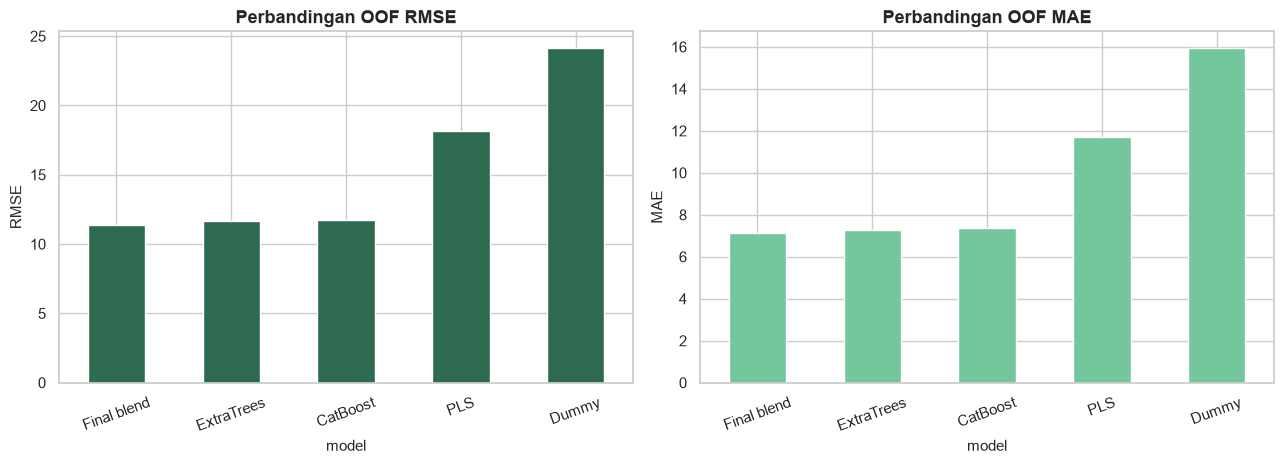

,feature,importance
38,source_id,20.2025
12,coarse_fine_ratio,6.9476
61,spectral_band_A_PC_5,5.6818
14,fine_fraction,4.5733
59,spectral_band_A_PC_3,3.6076
10,cation_exchange_capacity,3.5974
33,property_particle_coarse,3.5421
24,log_cec,3.4604
36,sampling_strategy,2.6395
57,spectral_band_A_PC_15,2.6045


In [27]:
_, axes = plt.subplots(1, 2, figsize=(13, 4.8))
benchmark["RMSE"].sort_values().plot(kind="bar", color=GREEN, ax=axes[0])
axes[0].set_title("Perbandingan OOF RMSE")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

benchmark["MAE"].sort_values().plot(kind="bar", color=LIGHT_GREEN, ax=axes[1])
axes[1].set_title("Perbandingan OOF MAE")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

mean_importance = (
    pd.concat(importance_rows, ignore_index=True)
    .groupby("feature", as_index=False)["importance"].mean()
    .sort_values("importance", ascending=False)
)
display(mean_importance.head(20))

In [28]:
best_model_name = benchmark.index[0]
rmse_gain_vs_catboost = benchmark.loc["CatBoost", "RMSE"] - benchmark.loc["Final blend", "RMSE"]
rmse_gain_vs_extratrees = benchmark.loc["ExtraTrees", "RMSE"] - benchmark.loc["Final blend", "RMSE"]

display(Markdown(f'''
## Jawaban Soal 8

Model yang digunakan pada pipeline submission terbaru adalah **weighted blend CatBoostRegressor dan
ExtraTreesRegressor** melalui 5-fold cross-validation. Bobot yang digunakan adalah
**{BLEND_CATBOOST_WEIGHT:.1%} CatBoost** dan **{BLEND_EXTRATREES_WEIGHT:.1%} ExtraTrees**.
Pada benchmark OOF, model dengan RMSE terendah adalah **{best_model_name}** dengan RMSE
**{benchmark.loc["Final blend", "RMSE"]:.3f}**.

Perbandingan model:

- CatBoost: RMSE **{benchmark.loc["CatBoost", "RMSE"]:.3f}**
- ExtraTrees: RMSE **{benchmark.loc["ExtraTrees", "RMSE"]:.3f}**
- Final blend: RMSE **{benchmark.loc["Final blend", "RMSE"]:.3f}**
- PLS: RMSE **{benchmark.loc["PLS", "RMSE"]:.3f}**
- Dummy median: RMSE **{benchmark.loc["Dummy", "RMSE"]:.3f}**

Blend dipilih karena kedua model membuat error yang tidak sepenuhnya identik. CatBoost kuat dalam
memanfaatkan fitur kategorikal, missing values, interaksi nonlinear, dan regularisasi boosting.
ExtraTrees memberi perspektif ensemble yang lebih teracak dan pada data ini memiliki OOF kompetitif.
Kombinasi keduanya menurunkan RMSE sebesar **{rmse_gain_vs_catboost:.3f}** dibanding CatBoost saja dan
**{rmse_gain_vs_extratrees:.3f}** dibanding ExtraTrees saja.

PLS tetap relevan sebagai pembanding karena merupakan metode klasik chemometrics untuk prediktor
spektral yang kolinear. Namun, PLS linear dan dalam benchmark ini hanya menggunakan fitur numerik,
sehingga kurang fleksibel untuk interaksi spektral-tanah-geografi.

Referensi:
[Prokhorenkova et al. - CatBoost](https://arxiv.org/abs/1706.09516);
[Wold et al. - PLS regression](https://doi.org/10.1016/S0169-7439(01)00155-1);
[Viscarra Rossel et al. - diffuse reflectance soil spectroscopy](https://doi.org/10.1016/j.geoderma.2005.03.007).

**Keterbatasan:** benchmark bukan hyperparameter search menyeluruh. Bobot blend dipilih dari eksperimen
OOF sederhana dan perlu divalidasi ulang bila data/split berubah.
'''))


## Jawaban Soal 8

Model yang digunakan pada pipeline submission terbaru adalah **weighted blend CatBoostRegressor dan
ExtraTreesRegressor** melalui 5-fold cross-validation. Bobot yang digunakan adalah
**47.5% CatBoost** dan **52.5% ExtraTrees**.
Pada benchmark OOF, model dengan RMSE terendah adalah **Final blend** dengan RMSE
**11.344**.

Perbandingan model:

- CatBoost: RMSE **11.700**
- ExtraTrees: RMSE **11.660**
- Final blend: RMSE **11.344**
- PLS: RMSE **18.174**
- Dummy median: RMSE **24.128**

Blend dipilih karena kedua model membuat error yang tidak sepenuhnya identik. CatBoost kuat dalam
memanfaatkan fitur kategorikal, missing values, interaksi nonlinear, dan regularisasi boosting.
ExtraTrees memberi perspektif ensemble yang lebih teracak dan pada data ini memiliki OOF kompetitif.
Kombinasi keduanya menurunkan RMSE sebesar **0.356** dibanding CatBoost saja dan
**0.316** dibanding ExtraTrees saja.

PLS tetap relevan sebagai pembanding karena merupakan metode klasik chemometrics untuk prediktor
spektral yang kolinear. Namun, PLS linear dan dalam benchmark ini hanya menggunakan fitur numerik,
sehingga kurang fleksibel untuk interaksi spektral-tanah-geografi.

Referensi:
[Prokhorenkova et al. - CatBoost](https://arxiv.org/abs/1706.09516);
[Wold et al. - PLS regression](https://doi.org/10.1016/S0169-7439(01)00155-1);
[Viscarra Rossel et al. - diffuse reflectance soil spectroscopy](https://doi.org/10.1016/j.geoderma.2005.03.007).

**Keterbatasan:** benchmark bukan hyperparameter search menyeluruh. Bobot blend dipilih dari eksperimen
OOF sederhana dan perlu divalidasi ulang bila data/split berubah.


# Soal 9 - Apakah RMSE tepat?

> **Menurut Anda, apakah metrik penilaian RMSE tepat untuk kasus prediksi kandungan organik tanah ini?
> Jika tidak, metrik apa yang lebih tepat? Elaborasikan jawaban Anda dengan mempertimbangkan
> karakteristik distribusi target!**

## Pendekatan dan asumsi

Metrik dibandingkan pada prediksi OOF final blend. Kontribusi squared error dihitung per desil target
untuk menunjukkan seberapa besar RMSE dipengaruhi bagian ekor distribusi.

,nilai
RMSE,11.3442
MAE,7.1144
MedianAE,4.5046
RMSLE,0.3030
R2,0.7609


,n,target_mean,MAE,MSE,squared_error_sum,share_total_squared_error
target_decile,,,,,,
"(2.156, 12.944]",1150,10.6120,7.2913,99.2262,"114,110.1503",0.0791
"(12.944, 16.18]",1109,15.0017,4.6016,50.6771,"56,200.9063",0.0390
"(16.18, 19.902]",1132,18.3424,3.9556,38.5367,"43,623.5246",0.0302
"(19.902, 24.27]",1465,22.5067,4.1713,40.4601,"59,274.1190",0.0411
"(24.27, 27.507]",890,26.2447,5.2233,76.3019,"67,908.6853",0.0471
"(27.507, 32.361]",1125,30.3316,5.8814,73.6255,"82,828.7369",0.0574
"(32.361, 38.833]",992,35.8663,6.3904,68.3002,"67,753.8407",0.0470
"(38.833, 48.541]",1160,44.0622,6.7722,78.7246,"91,320.5598",0.0633
"(48.541, 62.132]",1071,55.0126,8.3420,123.5844,"132,358.9099",0.0917


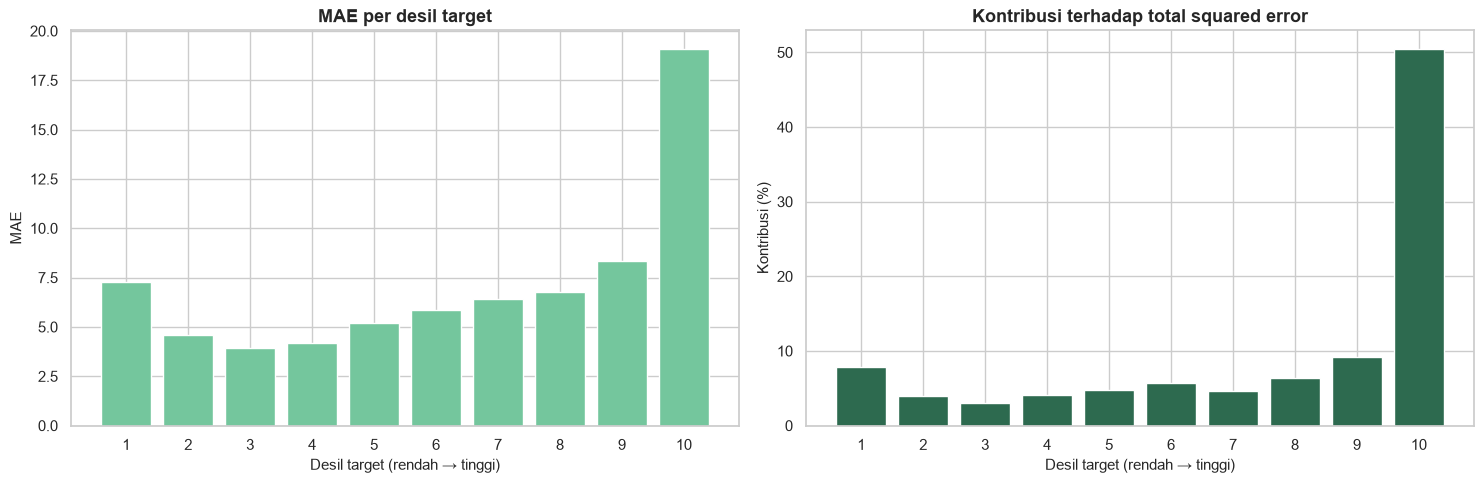

In [29]:
metric_comparison = pd.Series(regression_metrics(y, oof_pred), name="nilai")
error_analysis = pd.DataFrame({
    "actual": y,
    "prediction": oof_pred,
})
error_analysis["absolute_error"] = (
    error_analysis["actual"] - error_analysis["prediction"]
).abs()
error_analysis["squared_error"] = (
    error_analysis["actual"] - error_analysis["prediction"]
) ** 2
error_analysis["target_decile"] = pd.qcut(
    error_analysis["actual"], q=10, duplicates="drop"
)
decile_error = error_analysis.groupby(
    "target_decile", observed=True
).agg(
    n=("actual", "size"),
    target_mean=("actual", "mean"),
    MAE=("absolute_error", "mean"),
    MSE=("squared_error", "mean"),
    squared_error_sum=("squared_error", "sum"),
)
decile_error["share_total_squared_error"] = (
    decile_error["squared_error_sum"]
    / decile_error["squared_error_sum"].sum()
)

display(metric_comparison.to_frame())
display(decile_error)

_, axes = plt.subplots(1, 2, figsize=(15, 5))
decile_labels = [str(i + 1) for i in range(len(decile_error))]
axes[0].bar(decile_labels, decile_error["MAE"], color=LIGHT_GREEN)
axes[0].set_title("MAE per desil target")
axes[0].set_xlabel("Desil target (rendah → tinggi)")
axes[0].set_ylabel("MAE")

axes[1].bar(
    decile_labels, decile_error["share_total_squared_error"] * 100,
    color=GREEN
)
axes[1].set_title("Kontribusi terhadap total squared error")
axes[1].set_xlabel("Desil target (rendah → tinggi)")
axes[1].set_ylabel("Kontribusi (%)")
plt.tight_layout()
plt.show()

In [30]:
top_decile_share = decile_error.iloc[-1]["share_total_squared_error"] * 100
display(Markdown(f'''
## Jawaban Soal 9

**RMSE tepat sebagai metrik utama kompetisi apabila kesalahan besar dianggap jauh lebih mahal**, tetapi
tidak cukup sebagai satu-satunya metrik. Target memiliki skewness **{y.skew():.2f}** dengan ekor kanan
panjang. OOF RMSE adalah **{metric_comparison["RMSE"]:.3f}**, sedangkan MAE
**{metric_comparison["MAE"]:.3f}**, MedianAE **{metric_comparison["MedianAE"]:.3f}**, dan RMSLE
**{metric_comparison["RMSLE"]:.3f}**.

Desil target tertinggi menyumbang sekitar **{top_decile_share:.1f}%** dari total squared error. Ini
menunjukkan RMSE sangat sensitif terhadap sampel bernilai tinggi dan outlier. Sensitivitas tersebut dapat
diinginkan bila kegagalan pada tanah berkandungan sangat tinggi memiliki konsekuensi besar, tetapi dapat
membuat performa mayoritas sampel kurang terlihat.

**Rekomendasi:** pertahankan RMSE untuk konsistensi kompetisi, lalu dampingi dengan:

- MAE untuk error absolut rata-rata yang lebih robust;
- MedianAE untuk pengalaman sampel tipikal;
- RMSLE bila error relatif lebih penting;
- error per zona, bioma, ketersediaan band B, dan desil target untuk fairness/robustness.

Jadi, bukan mengganti RMSE sepenuhnya, melainkan menggunakan *metric portfolio* agar keputusan tidak
didominasi satu karakteristik distribusi.

**Keterbatasan:** pilihan metrik ideal seharusnya diturunkan dari biaya kesalahan operasional. Dataset
tidak menyediakan cost matrix atau ambang agronomis.
'''))


## Jawaban Soal 9

**RMSE tepat sebagai metrik utama kompetisi apabila kesalahan besar dianggap jauh lebih mahal**, tetapi
tidak cukup sebagai satu-satunya metrik. Target memiliki skewness **2.03** dengan ekor kanan
panjang. OOF RMSE adalah **11.344**, sedangkan MAE
**7.114**, MedianAE **4.505**, dan RMSLE
**0.303**.

Desil target tertinggi menyumbang sekitar **50.4%** dari total squared error. Ini
menunjukkan RMSE sangat sensitif terhadap sampel bernilai tinggi dan outlier. Sensitivitas tersebut dapat
diinginkan bila kegagalan pada tanah berkandungan sangat tinggi memiliki konsekuensi besar, tetapi dapat
membuat performa mayoritas sampel kurang terlihat.

**Rekomendasi:** pertahankan RMSE untuk konsistensi kompetisi, lalu dampingi dengan:

- MAE untuk error absolut rata-rata yang lebih robust;
- MedianAE untuk pengalaman sampel tipikal;
- RMSLE bila error relatif lebih penting;
- error per zona, bioma, ketersediaan band B, dan desil target untuk fairness/robustness.

Jadi, bukan mengganti RMSE sepenuhnya, melainkan menggunakan *metric portfolio* agar keputusan tidak
didominasi satu karakteristik distribusi.

**Keterbatasan:** pilihan metrik ideal seharusnya diturunkan dari biaya kesalahan operasional. Dataset
tidak menyediakan cost matrix atau ambang agronomis.


# Soal 10 — Data eksternal

> **Jika Anda boleh mengambil data eksternal, data tentang apa yang akan Anda ambil untuk meningkatkan
> akurasi prediksi kandungan organik tanah? Jelaskan alasan pemilihannya dan bagaimana data tersebut
> dapat diintegrasikan ke dalam pipeline pemodelan Anda!**

## Pendekatan dan asumsi

Prioritas dipilih berdasarkan proses pembentuk bahan organik: iklim, topografi, vegetasi/produktivitas,
penggunaan lahan, dan sifat tanah. Integrasi harus menggunakan lokasi dan informasi yang tersedia sebelum
tanggal sampling untuk mencegah leakage.

In [31]:
external_data_plan = pd.DataFrame([
    {
        "sumber": "ERA5-Land",
        "variabel": "rainfall, temperature, soil moisture, evapotranspiration",
        "nilai_tambah": "menggambarkan produksi biomassa dan laju dekomposisi",
        "integrasi": "spatial join + agregasi 1/3/5 tahun sebelum sampling",
        "risiko": "resolusi lebih kasar dari titik tanah",
    },
    {
        "sumber": "Copernicus DEM / SRTM",
        "variabel": "elevation, slope, aspect, curvature, wetness index",
        "nilai_tambah": "menangkap drainase, erosi, dan akumulasi material",
        "integrasi": "extract raster dan terrain derivatives pada koordinat",
        "risiko": "koordinat hilang pada banyak sampel",
    },
    {
        "sumber": "Sentinel-2 / Landsat",
        "variabel": "NDVI/EVI, bare-soil index, moisture, burn history",
        "nilai_tambah": "proxy vegetasi, residu, gangguan, dan perubahan tutupan",
        "integrasi": "cloud masking + seasonal composites sebelum sampling",
        "risiko": "awan, tanggal sampling, dan mixed pixels",
    },
    {
        "sumber": "SoilGrids",
        "variabel": "clay, silt, sand, bulk density, SOC, pH",
        "nilai_tambah": "prior spasial sifat tanah global",
        "integrasi": "extract per depth yang sesuai 0–20 cm",
        "risiko": "target leakage bila memakai layer SOC kontemporer tanpa audit",
    },
    {
        "sumber": "MapBiomas Brasil",
        "variabel": "land-cover history, transition, fire, agriculture/pasture age",
        "nilai_tambah": "riwayat penggunaan lahan lebih informatif dari label snapshot",
        "integrasi": "annual history + transition counts sebelum sampling",
        "risiko": "ketidakselarasan tahun dan klasifikasi",
    },
])
display(external_data_plan)

,sumber,variabel,nilai_tambah,integrasi,risiko
0,ERA5-Land,"rainfall, temperature, soil moisture, evapotra...",menggambarkan produksi biomassa dan laju dekom...,spatial join + agregasi 1/3/5 tahun sebelum sa...,resolusi lebih kasar dari titik tanah
1,Copernicus DEM / SRTM,"elevation, slope, aspect, curvature, wetness i...","menangkap drainase, erosi, dan akumulasi material",extract raster dan terrain derivatives pada ko...,koordinat hilang pada banyak sampel
2,Sentinel-2 / Landsat,"NDVI/EVI, bare-soil index, moisture, burn history","proxy vegetasi, residu, gangguan, dan perubaha...",cloud masking + seasonal composites sebelum sa...,"awan, tanggal sampling, dan mixed pixels"
3,SoilGrids,"clay, silt, sand, bulk density, SOC, pH",prior spasial sifat tanah global,extract per depth yang sesuai 0–20 cm,target leakage bila memakai layer SOC kontempo...
4,MapBiomas Brasil,"land-cover history, transition, fire, agricult...",riwayat penggunaan lahan lebih informatif dari...,annual history + transition counts sebelum sam...,ketidakselarasan tahun dan klasifikasi


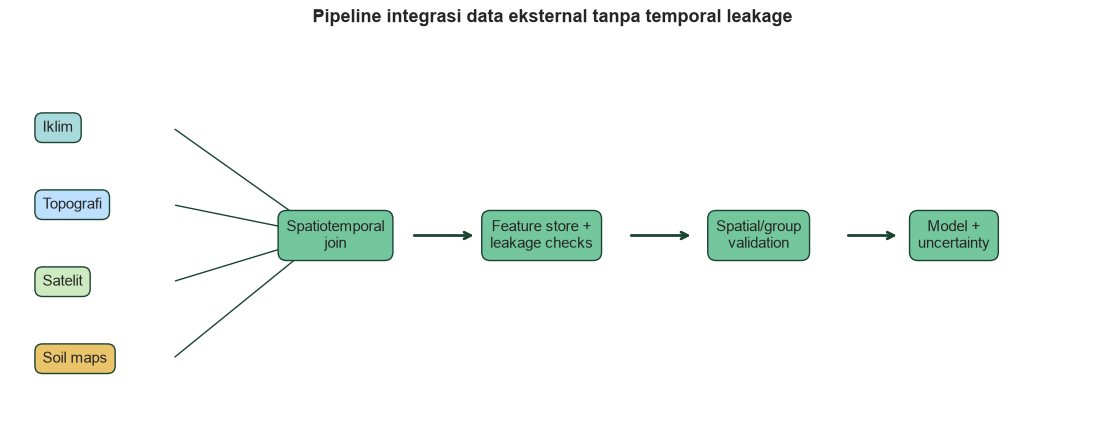

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
sources = [
    (0.03, 0.78, "Iklim", "#A8DADC"),
    (0.03, 0.58, "Topografi", "#BDE0FE"),
    (0.03, 0.38, "Satelit", "#CDEAC0"),
    (0.03, 0.18, "Soil maps", "#E9C46A"),
]
for x, y_pos, label, color in sources:
    ax.text(x, y_pos, label, va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", fc=color, ec=DARK_GREEN))
    ax.annotate("", xy=(0.29, 0.5), xytext=(0.15, y_pos),
                arrowprops=dict(arrowstyle="->", color=DARK_GREEN))
pipeline_boxes = [
    (0.30, "Spatiotemporal\njoin"),
    (0.49, "Feature store +\nleakage checks"),
    (0.69, "Spatial/group\nvalidation"),
    (0.87, "Model +\nuncertainty"),
]
for x, label in pipeline_boxes:
    ax.text(x, 0.5, label, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.55", fc=LIGHT_GREEN, ec=DARK_GREEN))
for x1, x2 in [(0.37, 0.43), (0.57, 0.63), (0.77, 0.82)]:
    ax.annotate("", xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle="->", lw=2, color=DARK_GREEN))
ax.set_title("Pipeline integrasi data eksternal tanpa temporal leakage", pad=15)
plt.show()

## Jawaban Soal 10

Prioritas pertama adalah **iklim historis, topografi, riwayat vegetasi/tutupan lahan, dan sifat tanah
resolusi tinggi**. Variabel tersebut mengisi mekanisme yang belum diobservasi oleh spektrum dan kategori
wilayah.

Pipeline:

1. validasi CRS dan kualitas koordinat;
2. spatial join raster ke titik sampling;
3. agregasi temporal hanya dari periode sebelum sampling;
4. rekayasa fitur tren, seasonal variability, dan perubahan tutupan;
5. feature store dengan metadata sumber, resolusi, dan tanggal;
6. evaluasi menggunakan spatial/group blocking;
7. ablation untuk memastikan setiap sumber benar-benar menambah generalisasi.

SoilGrids SOC harus diperlakukan hati-hati karena dapat menjadi proxy target dan menimbulkan leakage atau
circularity. Lebih aman memulai dari clay, bulk density, pH, dan covariate non-target; jika layer SOC
digunakan, tahun, sumber observasi, dan overlap training harus diaudit.

Sumber resmi:

- [ERA5-Land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview)
- [Copernicus DEM](https://dataspace.copernicus.eu/explore-data/data-collections/copernicus-contributing-missions/collections-description/COP-DEM)
- [Sentinel-2](https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html)
- [SoilGrids](https://isric.org/explore/soilgrids)
- [MapBiomas Brasil](https://brasil.mapbiomas.org/en/)

**Keterbatasan:** hampir 79% koordinat pada dataset hilang. Integrasi raster hanya dapat dilakukan setelah
memperoleh koordinat yang lebih lengkap atau kunci lokasi administratif yang dapat dipetakan.

## Executive summary

In [33]:
display(Markdown(f'''
1. Prediksi SOC penting sebagai alat screening untuk mengarahkan biaya sampling dan tindakan konservasi.
2. Final blend CatBoost + ExtraTrees mencapai OOF RMSE **{oof_metrics["RMSE"]:.3f}** dan R^2
   **{oof_metrics["R2"]:.3f}**, tetapi train-validation gap serta GroupKFold menunjukkan domain shift
   sumber perlu diperhatikan.
3. Distribusi antar zona macro berbeda signifikan dengan epsilon-squared **{epsilon_squared:.3f}**.
4. Rasio mean antar kelompok meningkat pada resolusi geografis yang lebih lokal.
5. Analisis acidity/KTK harus mempertimbangkan sample size dan missingness; outlier tidak otomatis salah.
6. Multikolinearitas utama muncul pada tekstur kasar-halus dan Ca-Mg.
7. Ablation menunjukkan kontribusi empiris kelompok feature engineering yang diselaraskan dengan pipeline submission.
8. Benchmark menempatkan **{best_model_name}** sebagai model dengan RMSE terendah pada konfigurasi ini.
9. RMSE relevan, tetapi perlu didampingi MAE, MedianAE, RMSLE, dan audit per kelompok.
10. Data iklim, topografi, satelit, SoilGrids, dan MapBiomas paling menjanjikan bila leakage dikendalikan.
'''))


1. Prediksi SOC penting sebagai alat screening untuk mengarahkan biaya sampling dan tindakan konservasi.
2. Final blend CatBoost + ExtraTrees mencapai OOF RMSE **11.344** dan R^2
   **0.761**, tetapi train-validation gap serta GroupKFold menunjukkan domain shift
   sumber perlu diperhatikan.
3. Distribusi antar zona macro berbeda signifikan dengan epsilon-squared **0.066**.
4. Rasio mean antar kelompok meningkat pada resolusi geografis yang lebih lokal.
5. Analisis acidity/KTK harus mempertimbangkan sample size dan missingness; outlier tidak otomatis salah.
6. Multikolinearitas utama muncul pada tekstur kasar-halus dan Ca-Mg.
7. Ablation menunjukkan kontribusi empiris kelompok feature engineering yang diselaraskan dengan pipeline submission.
8. Benchmark menempatkan **Final blend** sebagai model dengan RMSE terendah pada konfigurasi ini.
9. RMSE relevan, tetapi perlu didampingi MAE, MedianAE, RMSLE, dan audit per kelompok.
10. Data iklim, topografi, satelit, SoilGrids, dan MapBiomas paling menjanjikan bila leakage dikendalikan.


## Daftar referensi

1. FAO Global Soil Partnership. **Soil Organic Carbon**.
   https://www.fao.org/global-soil-partnership/areas-of-work/soil-organic-carbon/en/
2. IPCC. **Special Report on Climate Change and Land**.
   https://www.ipcc.ch/srccl/
3. Prokhorenkova, L., et al. (2018). **CatBoost: unbiased boosting with categorical features**.
   https://arxiv.org/abs/1706.09516
4. Wold, S., Sjöström, M., & Eriksson, L. (2001). **PLS-regression: a basic tool of chemometrics**.
   https://doi.org/10.1016/S0169-7439(01)00155-1
5. Viscarra Rossel, R. A., et al. (2006). **Visible, near infrared, mid infrared or combined diffuse
   reflectance spectroscopy for simultaneous assessment of various soil properties**.
   https://doi.org/10.1016/j.geoderma.2005.03.007
6. Copernicus Climate Data Store. **ERA5-Land**.
   https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview
7. Copernicus Data Space Ecosystem. **Copernicus DEM**.
   https://dataspace.copernicus.eu/explore-data/data-collections/copernicus-contributing-missions/collections-description/COP-DEM
8. Copernicus Data Space Ecosystem. **Sentinel-2 documentation**.
   https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html
9. ISRIC. **SoilGrids — global gridded soil information**.
   https://isric.org/explore/soilgrids
10. MapBiomas Brasil. **Land cover and land use mapping**.
    https://brasil.mapbiomas.org/en/
11. IBGE. **Biomes of Brazil**.
    https://www.ibge.gov.br/en/geosciences/environmental-information/vegetation/18391-biomes.html